# HD Model Parameter Space — Exploration
Compiled results from `DoVM_model_slurm.py` → CANN optimization per cell.

In [117]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [118]:
#PARQUET = Path(r"\\172.25.250.112\burgalossi\lab_share\Data\Florian\HD-model\optimized_cells.parquet")
PARQUET = Path(r"\\172.25.250.112\burgalossi\lab_share\Data\Florian\HD-model\optimized_cells_spatial_included.parquet")

df = pd.read_parquet(PARQUET)

PARAM_COLS = [
    "I_baseline", "A_fast", "A_phasic", "tau_decay",
    "J1", "KAPPA", "J0", "U_floor",
    "T_phasic", "tau_neural", "fc_stim_duration", "t_delay",
]
BIO_COLS = [
    "HDpeakFRsmooth", "HDpeakFR", "HDInx", "pValS", "pValR",
    "nSpk", "HDFR", "HDAngle",
    "vm_deltaBIC", "vm_deltaAIC", "vm_deltaLL",
    "vm_mu1_deg", "vm_mu2_deg", "vm_kappa", "vm_kappa2",
    "vm_pi", "vm_mu_uni_deg", "vm_kappa_uni",
]
FIT_COLS = ["Loss_100N", "Loss_360N", "R_Squared"]

# Good-fit subset: R² > 0.7
df_good = df[df["R_Squared"] > 0.7].copy()

print(f"Total cells  : {len(df)}")
print(f"Good fit (R²>0.7): {len(df_good)}")
print(f"Columns : {df.shape[1]}")
df.describe().T

Total cells  : 77
Good fit (R²>0.7): 61
Columns : 35


,count,mean,std,min,25%,50%,75%,max
Cell_Id,77.0,9.884416e+01,3.841945e+01,1.000000,69.000000,9.000000e+01,1.200000e+02,1.730000e+02
Loss_100N,77.0,5.665057e+01,4.452930e+01,2.804610,24.366449,4.222965e+01,7.503210e+01,2.046318e+02
Loss_360N,77.0,6.572065e+01,5.698577e+01,9.293643,26.475244,4.783152e+01,7.996317e+01,3.419652e+02
R_Squared,77.0,7.482779e-01,1.504157e-01,0.020180,0.718238,7.885244e-01,8.331807e-01,9.332028e-01
I_baseline,77.0,3.596401e+01,2.038255e+01,5.000000,18.720016,4.046803e+01,5.627798e+01,6.000000e+01
A_fast,77.0,2.373531e+03,6.198718e+02,246.332423,2133.545806,2.562094e+03,2.809023e+03,2.985853e+03
A_phasic,77.0,5.856595e+01,2.585628e+01,10.000000,40.940712,5.460221e+01,7.888635e+01,1.116559e+02
tau_decay,77.0,2.397325e+02,1.395932e+02,20.000000,148.257672,2.163483e+02,3.332877e+02,5.000000e+02
J1,77.0,1.089504e+01,2.121964e+00,8.007241,9.495811,1.056951e+01,1.193346e+01,2.032404e+01
KAPPA,77.0,7.937144e+00,5.417106e+00,2.000000,3.132836,7.199187e+00,1.126965e+01,2.000000e+01


## Fit quality

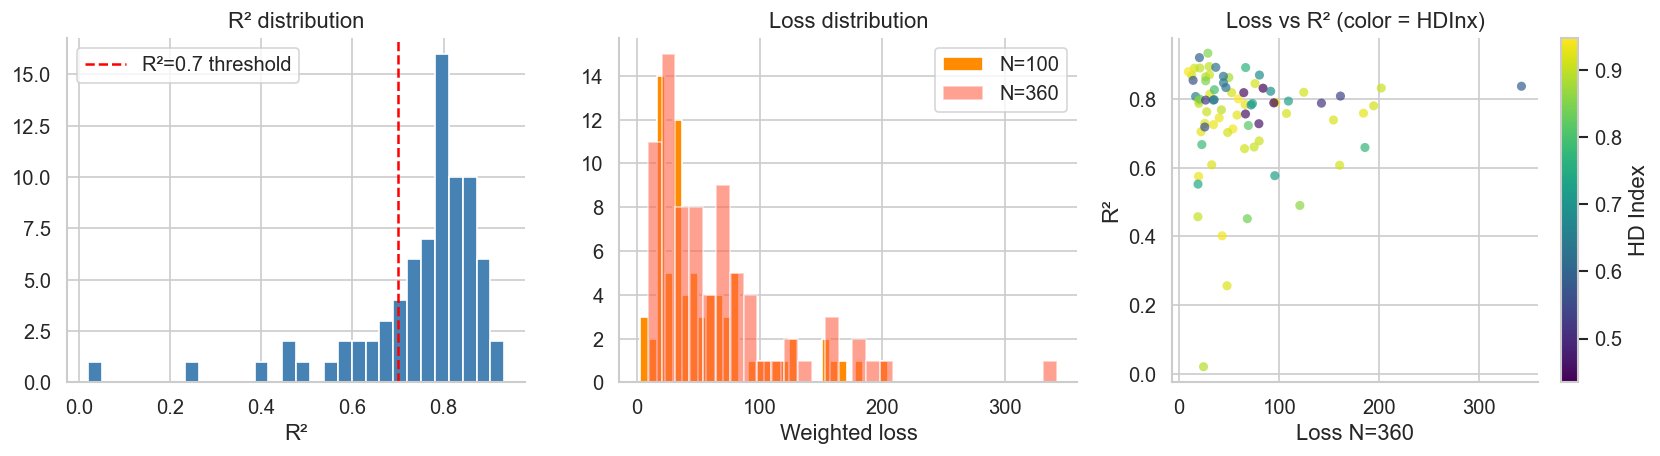

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["R_Squared"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0.7, color="red", linestyle="--", label="R²=0.7 threshold")
axes[0].set_xlabel("R²")
axes[0].set_title("R² distribution")
axes[0].legend()

axes[1].hist(df["Loss_100N"].dropna(), bins=30, color="darkorange", edgecolor="white", label="N=100")
axes[1].hist(df["Loss_360N"].dropna(), bins=30, color="tomato", edgecolor="white", alpha=0.6, label="N=360")
axes[1].set_xlabel("Weighted loss")
axes[1].set_title("Loss distribution")
axes[1].legend()

axes[2].scatter(df["Loss_360N"], df["R_Squared"], c=df["HDInx"], cmap="viridis",
                s=30, alpha=0.7, edgecolors="none")
sm = plt.cm.ScalarMappable(cmap="viridis",
     norm=plt.Normalize(df["HDInx"].min(), df["HDInx"].max()))
fig.colorbar(sm, ax=axes[2], label="HD Index")
axes[2].set_xlabel("Loss N=360")
axes[2].set_ylabel("R²")
axes[2].set_title("Loss vs R² (color = HDInx)")

plt.tight_layout()
plt.show()

## Model parameter distributions

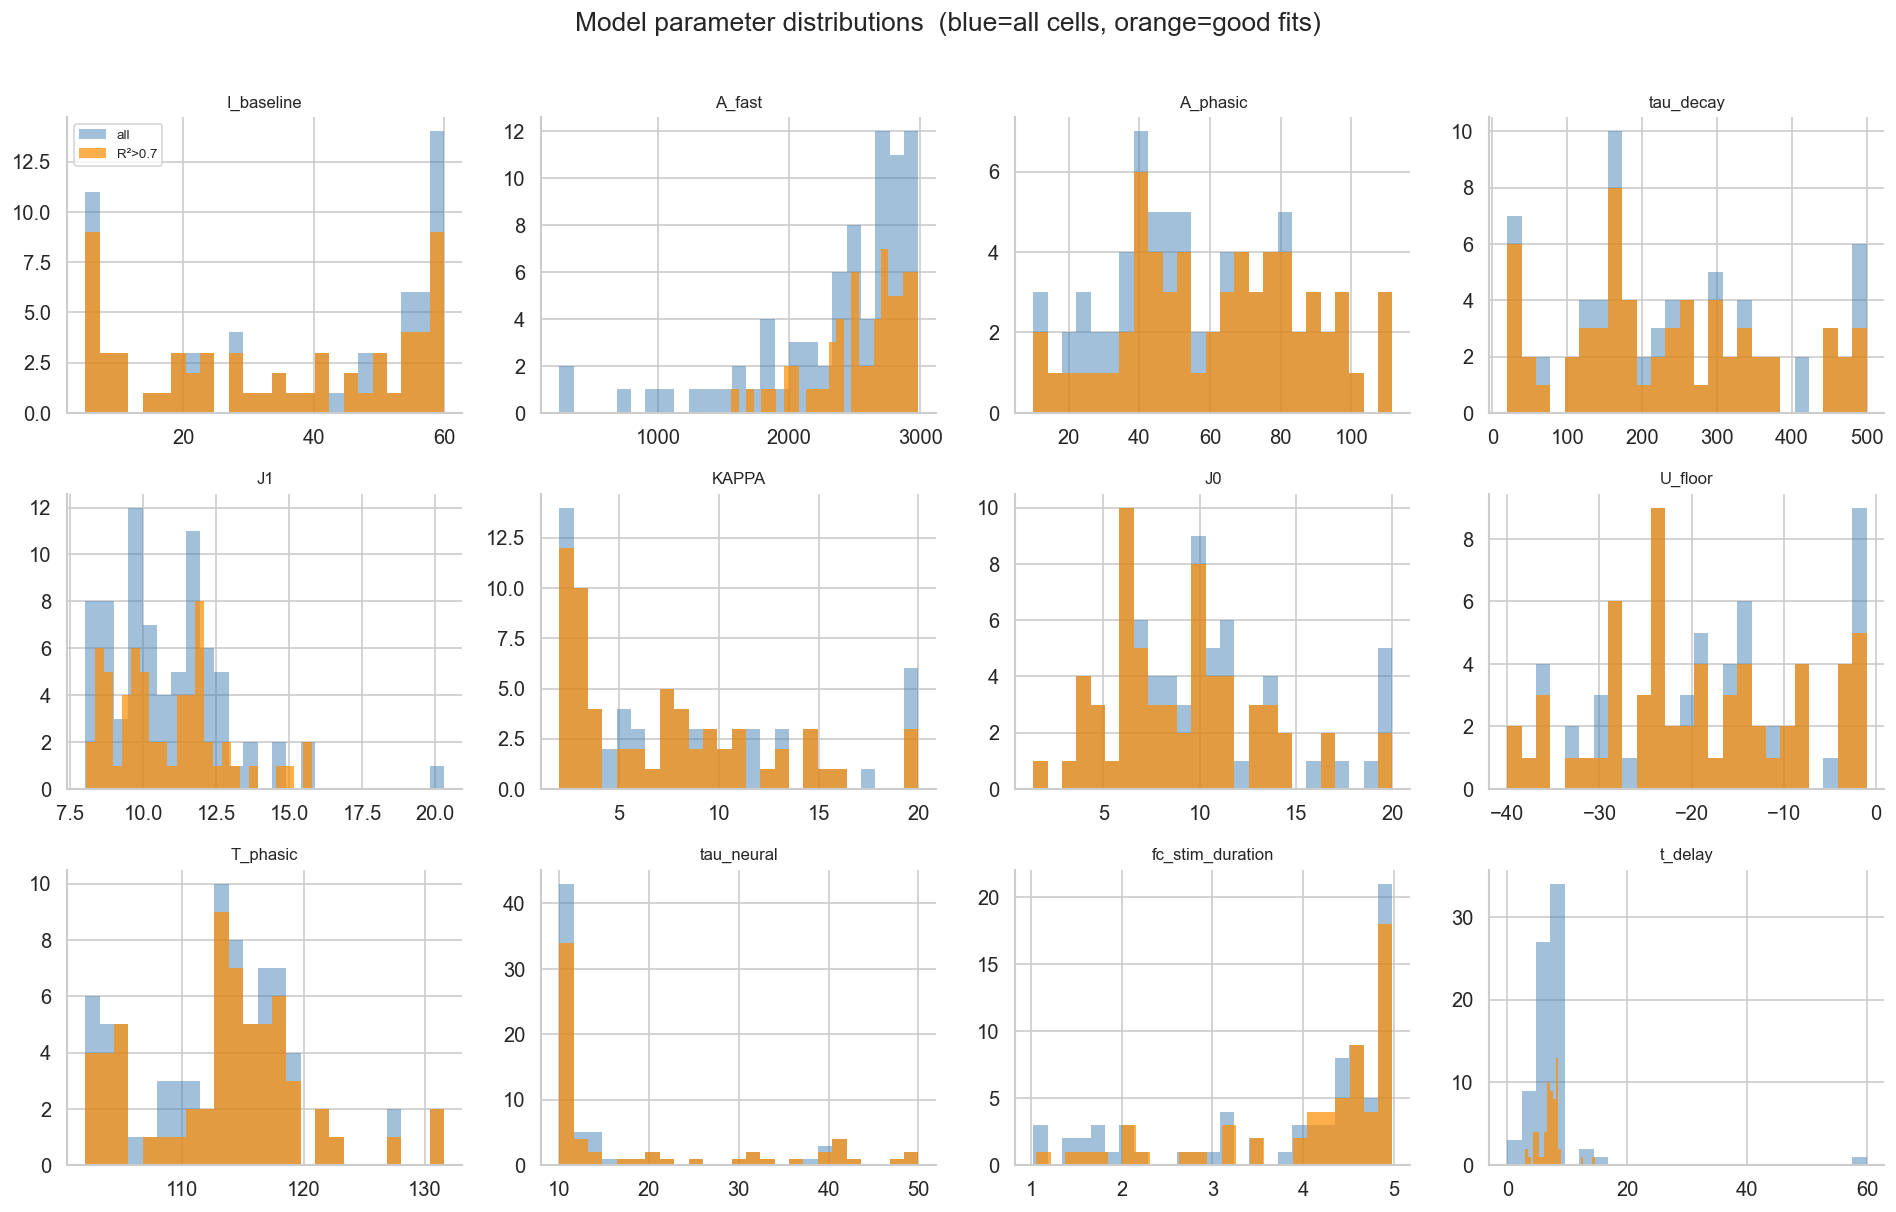

In [120]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, PARAM_COLS):
    vals_all  = df[col].dropna()
    vals_good = df_good[col].dropna()
    ax.hist(vals_all,  bins=25, color="steelblue",  alpha=0.5, label="all",      edgecolor="none")
    ax.hist(vals_good, bins=25, color="darkorange", alpha=0.7, label="R²>0.7",   edgecolor="none")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

axes[0].legend(fontsize=8)
fig.suptitle("Model parameter distributions  (blue=all cells, orange=good fits)", y=1.01)
plt.tight_layout()
plt.show()

## Biological metrics distributions

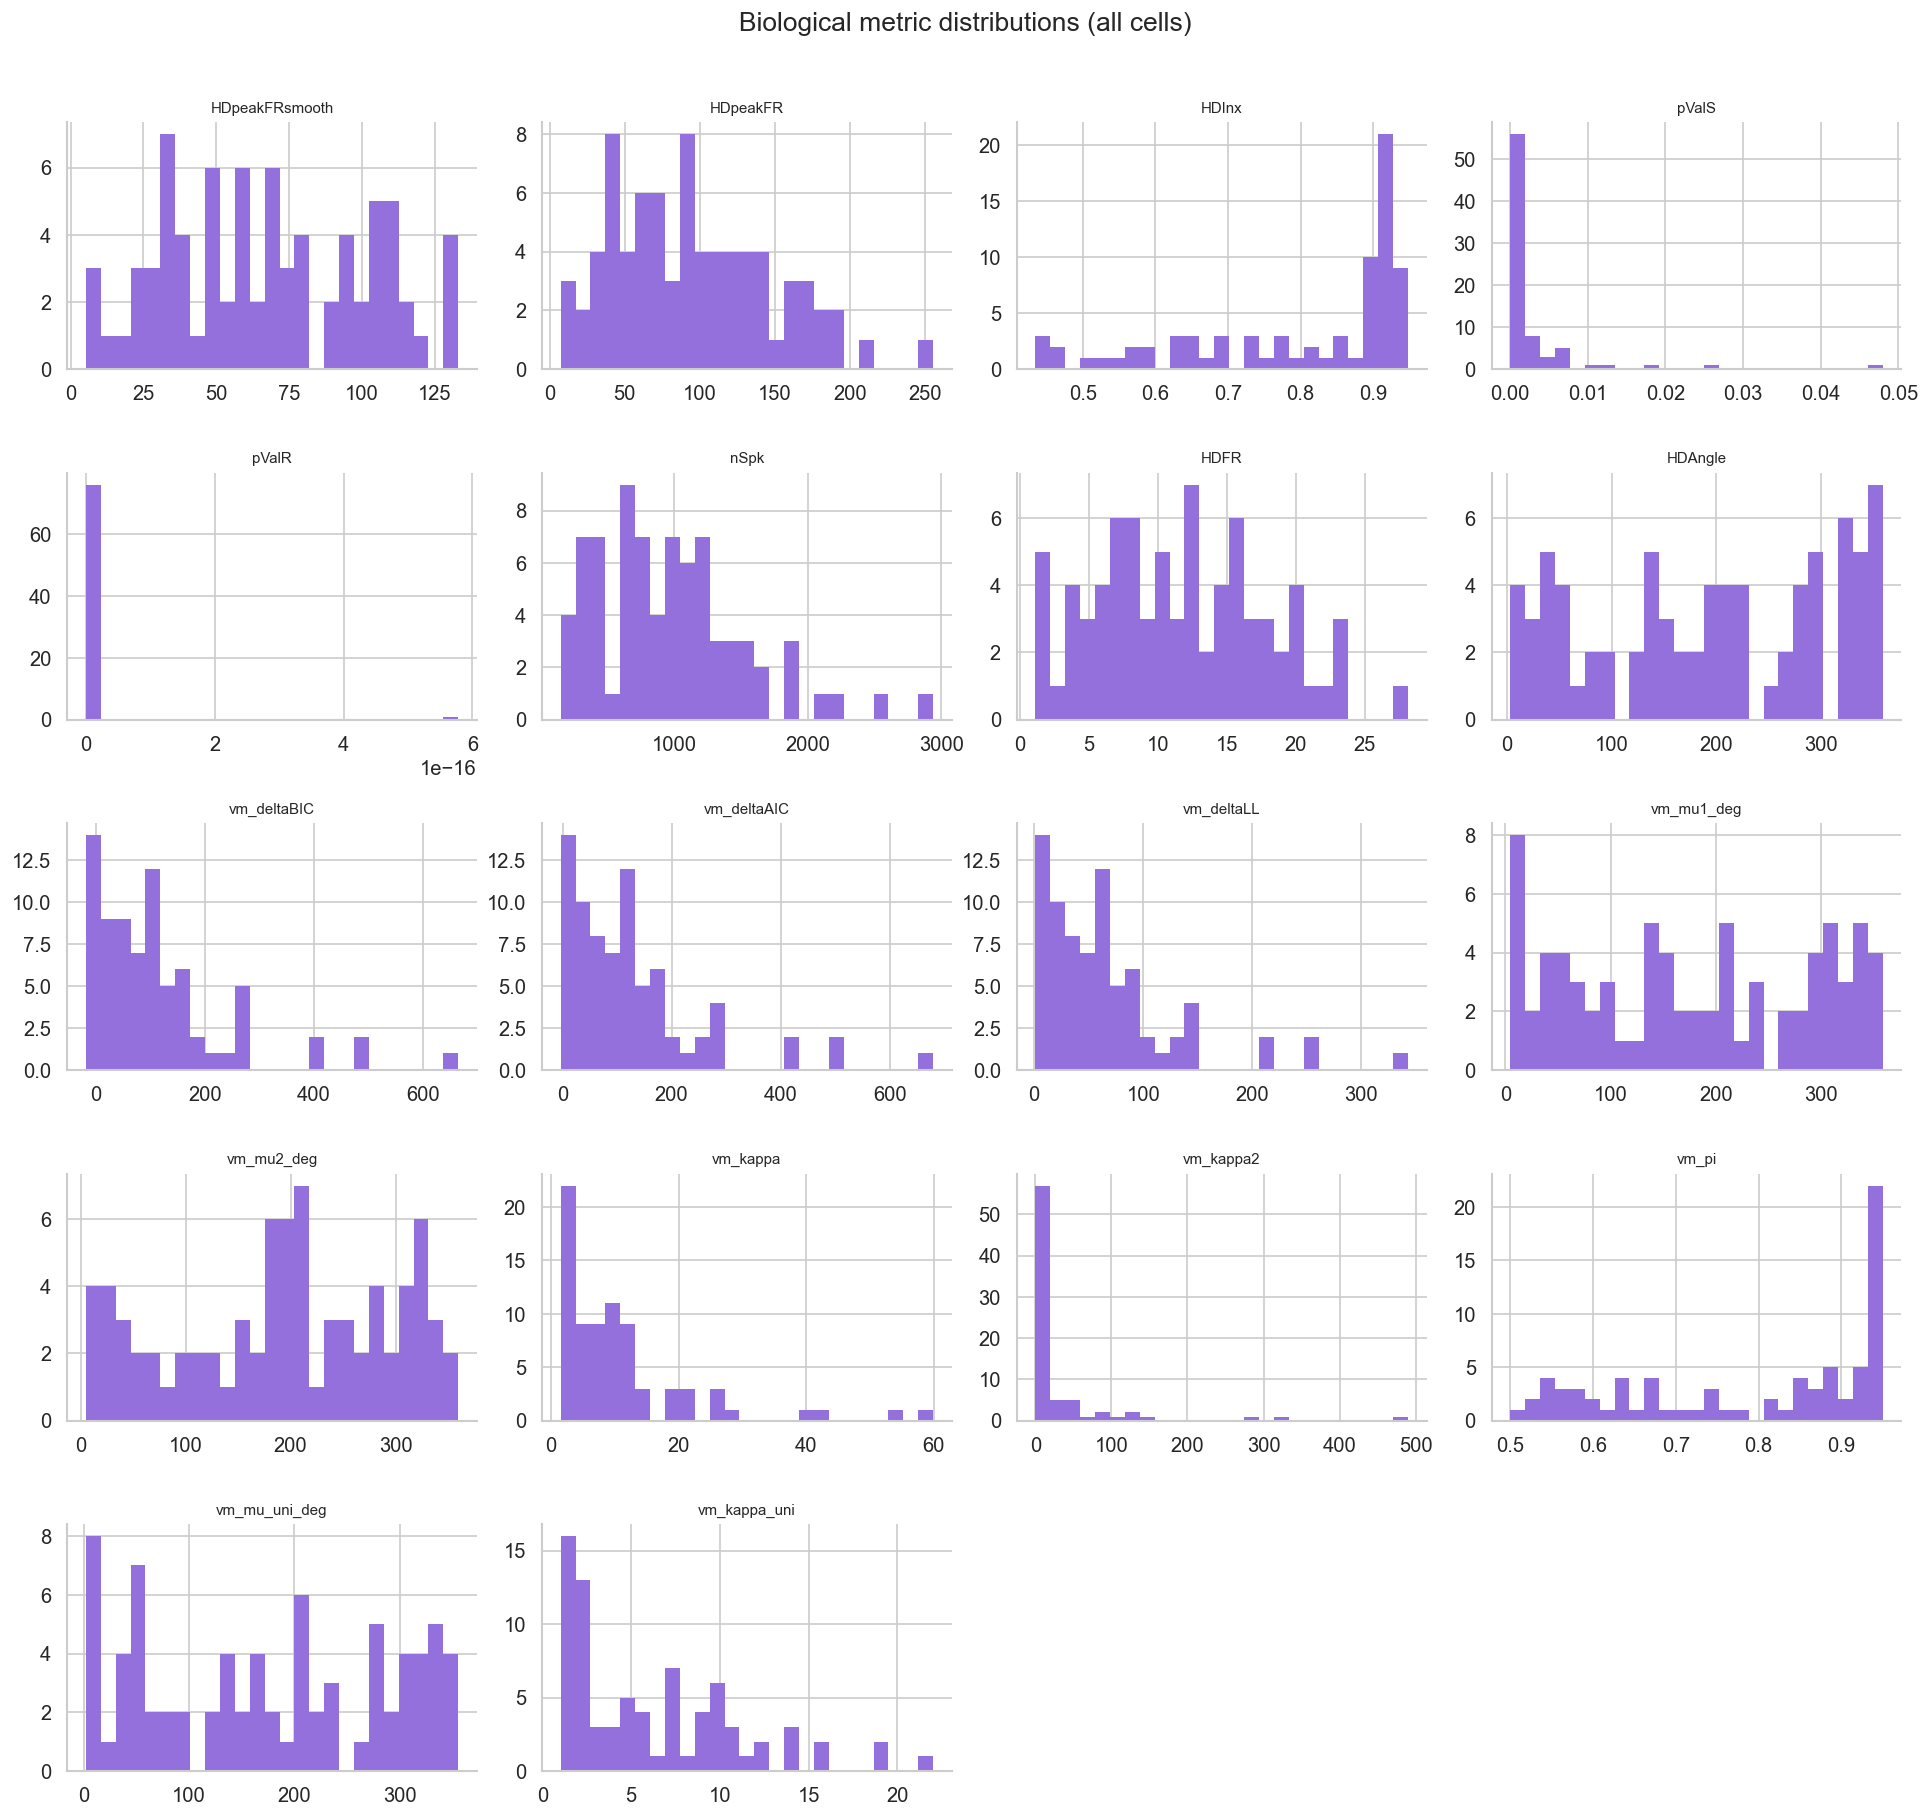

In [121]:
def _finite(s: pd.Series) -> pd.Series:
    return s[np.isfinite(s)]

bio_plot = [c for c in BIO_COLS if _finite(df[c]).shape[0] > 5]
ncols = 4
nrows = int(np.ceil(len(bio_plot) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, bio_plot):
    ax.hist(_finite(df[col]), bins=25, color="mediumpurple", edgecolor="none")
    ax.set_title(col, fontsize=9)

for ax in axes[len(bio_plot):]:
    ax.set_visible(False)

fig.suptitle("Biological metric distributions (all cells)", y=1.01)
plt.tight_layout()
plt.show()

## Correlation matrix

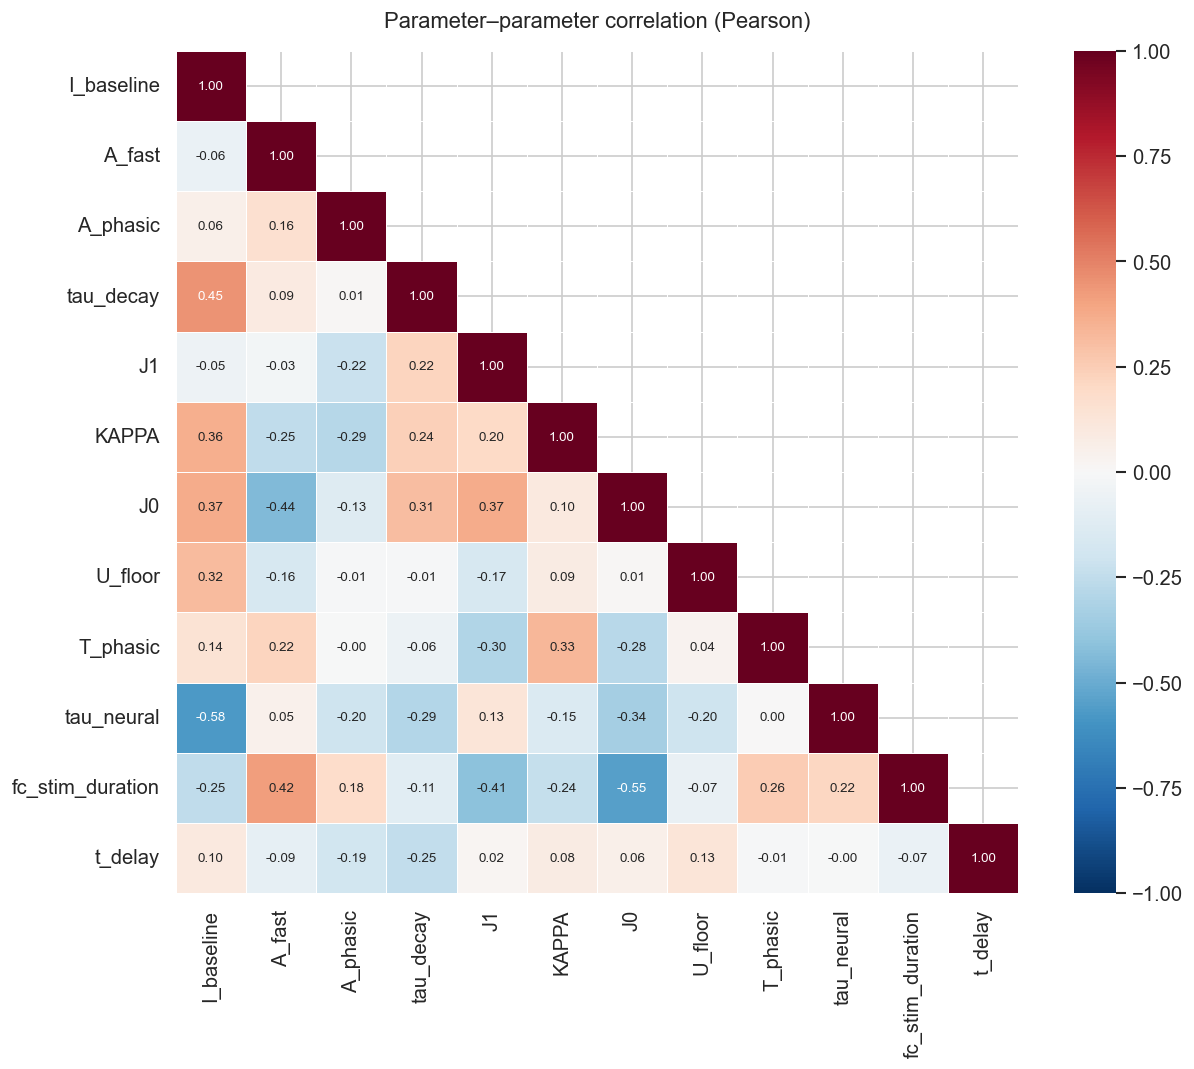

In [122]:
# Full parameter–parameter correlation
corr_params = df[PARAM_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_params, dtype=bool), k=1)
sns.heatmap(
    corr_params, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax,
)
ax.set_title("Parameter–parameter correlation (Pearson)", pad=14)
plt.tight_layout()
plt.show()

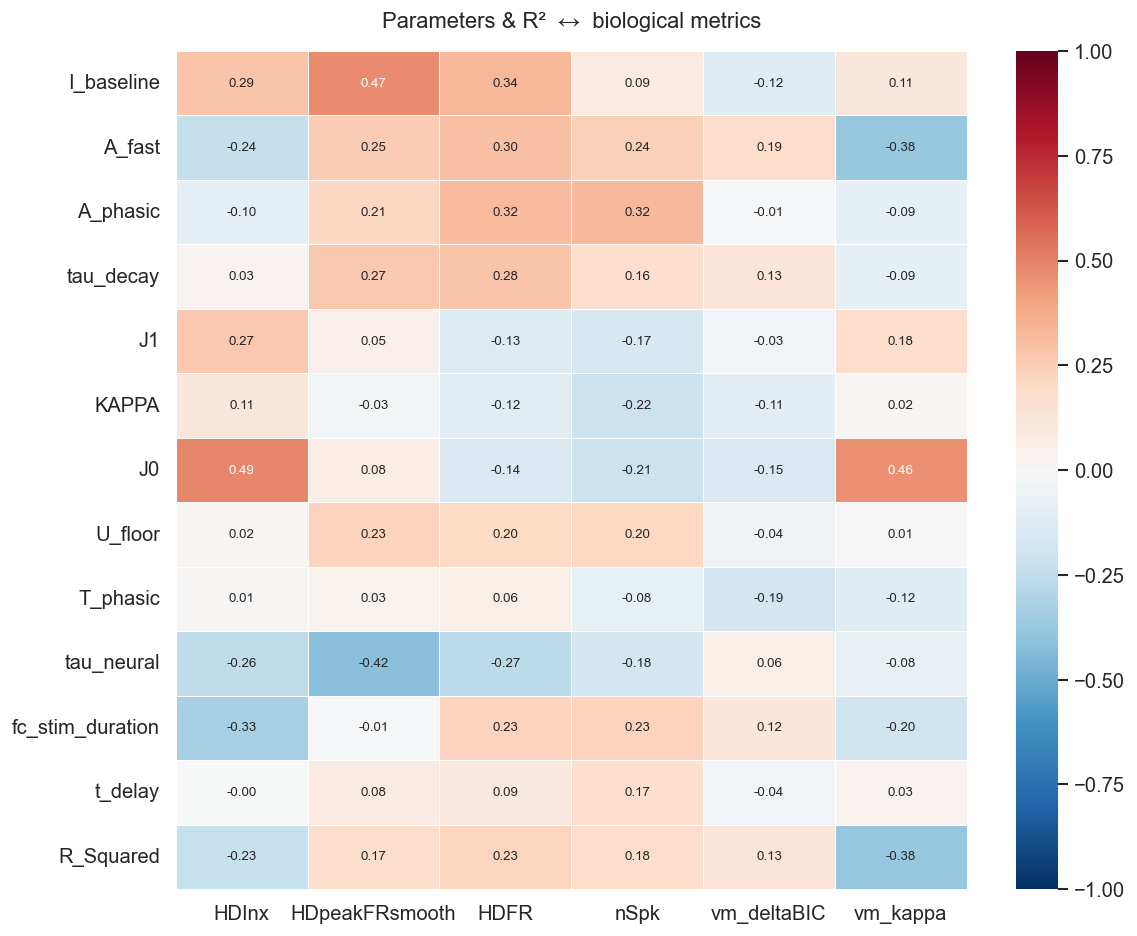

In [123]:
# Parameters vs biological metrics + fit quality
cross_cols = PARAM_COLS + ["R_Squared"]
bio_valid  = [c for c in ["HDInx", "HDpeakFRsmooth", "HDFR", "nSpk",
                           "vm_deltaBIC", "vm_kappa"] if c in df.columns]

cross_corr = df[cross_cols + bio_valid].corr().loc[cross_cols, bio_valid]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cross_corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax,
)
ax.set_title("Parameters & R²  ↔  biological metrics", pad=14)
plt.tight_layout()
plt.show()

## Derived parameter ratios — hidden biological balances
Three mechanistic ratios that compress correlated parameters into interpretable quantities:
- **E/I balance** `J1/J0` — ratio of local excitation to global inhibition; drives attractor sharpness
- **Membrane reactivity** `A_fast/τ_neural` — startle current divided by membrane time-constant; determines peak response magnitude
- **Phasic energy** `A_phasic × T_phasic` — amplitude × onset-time of phasic drive; total late-phase input budget

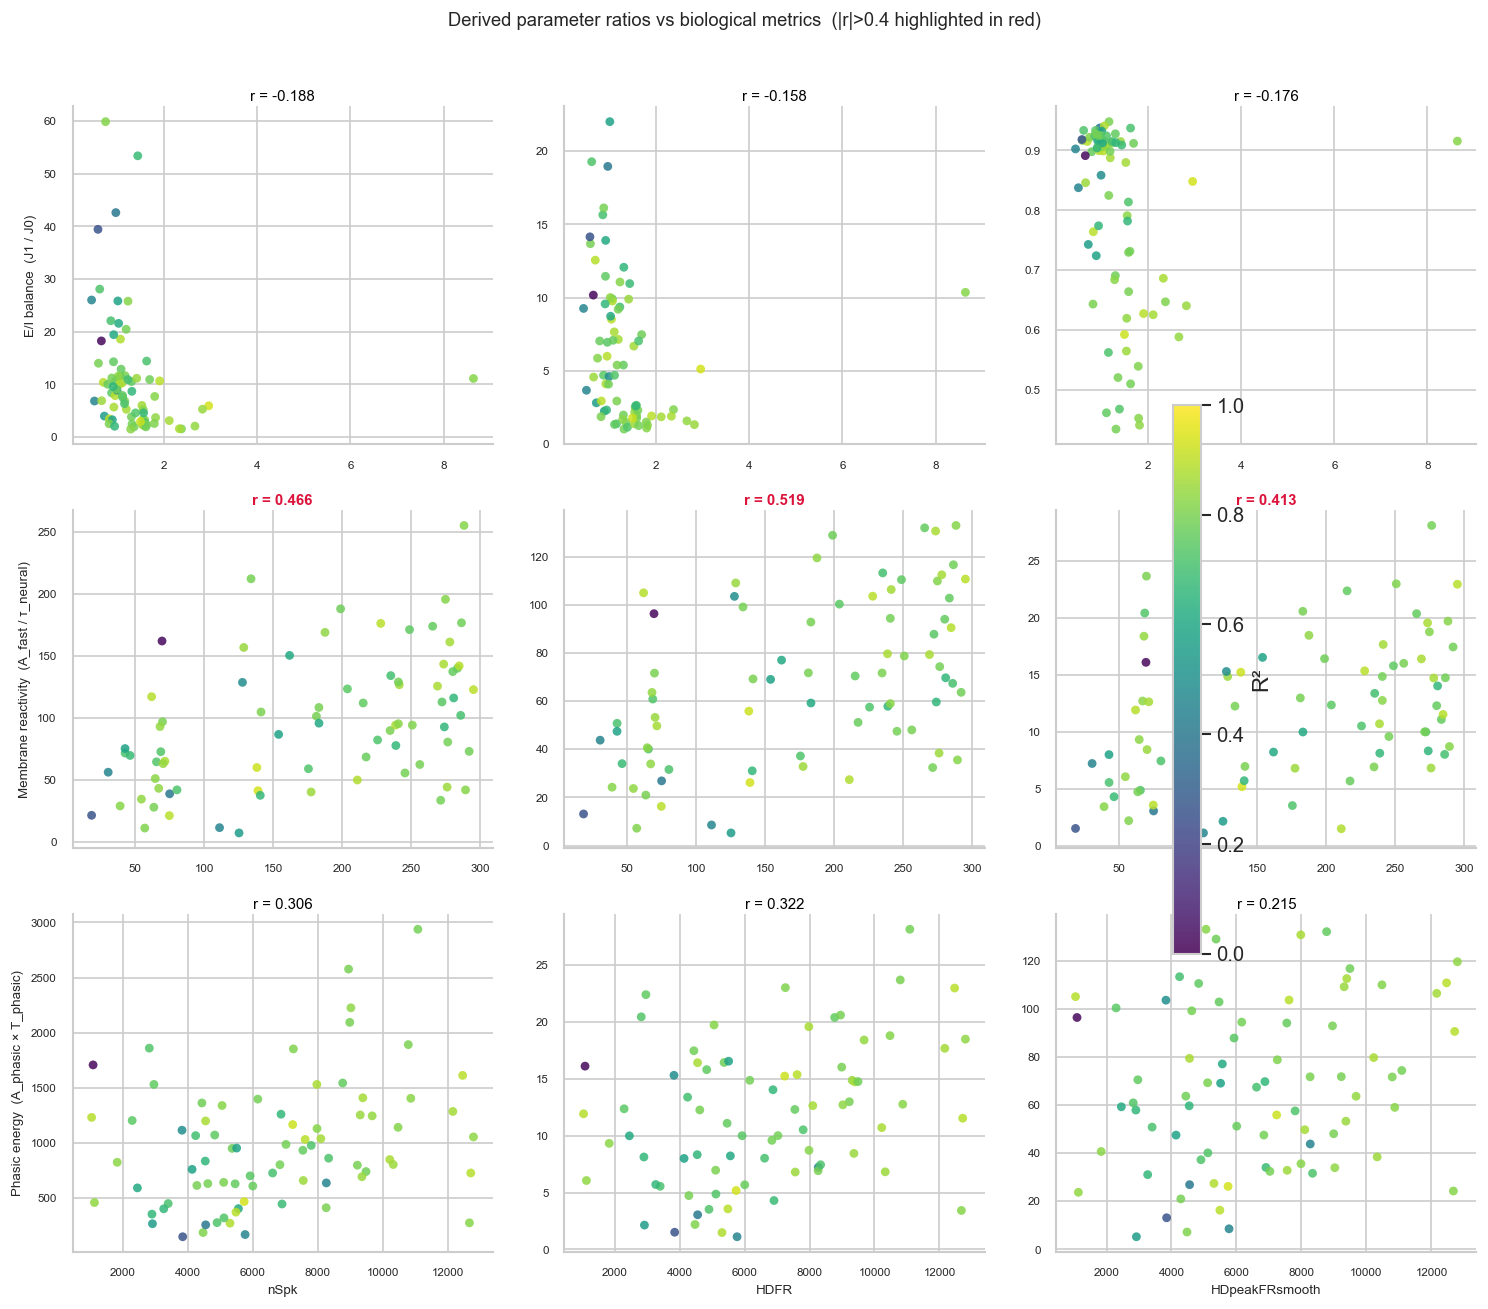

Pearson r — ratio vs biological target:

  Ratio                                  Bio metric             r
  --------------------------------------------------------------------
  E/I balance  (J1 / J0)                 vm_kappa               -0.188
  E/I balance  (J1 / J0)                 vm_kappa_uni           -0.158
  E/I balance  (J1 / J0)                 HDInx                  -0.176

  Membrane reactivity  (A_fast / τ_neural) HDpeakFR               +0.466  ← strong
  Membrane reactivity  (A_fast / τ_neural) HDpeakFRsmooth         +0.519  ← strong
  Membrane reactivity  (A_fast / τ_neural) HDFR                   +0.413  ← strong

  Phasic energy  (A_phasic × T_phasic)   nSpk                   +0.306
  Phasic energy  (A_phasic × T_phasic)   HDFR                   +0.322
  Phasic energy  (A_phasic × T_phasic)   HDpeakFRsmooth         +0.215



In [124]:
# ── compute derived ratios ────────────────────────────────────────────────
df["EI_balance"]          = df["J1"] / df["J0"]
df["membrane_reactivity"] = df["A_fast"] / df["tau_neural"]
df["phasic_energy"]       = df["A_phasic"] * df["T_phasic"]

RATIO_COLS = ["EI_balance", "membrane_reactivity", "phasic_energy"]
RATIO_LABELS = {
    "EI_balance":          "E/I balance  (J1 / J0)",
    "membrane_reactivity": "Membrane reactivity  (A_fast / τ_neural)",
    "phasic_energy":       "Phasic energy  (A_phasic × T_phasic)",
}
ratio_targets = {
    "EI_balance":          ["vm_kappa", "vm_kappa_uni", "HDInx"],
    "membrane_reactivity": ["HDpeakFR",  "HDpeakFRsmooth", "HDFR"],
    "phasic_energy":       ["nSpk",      "HDFR",           "HDpeakFRsmooth"],
}

max_targets = max(len(v) for v in ratio_targets.values())
fig, axes = plt.subplots(len(RATIO_COLS), max_targets,
                          figsize=(max_targets * 4.2, len(RATIO_COLS) * 3.6))

for row_i, ratio in enumerate(RATIO_COLS):
    targets = ratio_targets[ratio]
    for col_j in range(max_targets):
        ax = axes[row_i, col_j]
        if col_j >= len(targets):
            ax.set_visible(False)
            continue
        bio = targets[col_j]
        sub = df[[ratio, bio, "R_Squared"]].replace([np.inf, -np.inf], np.nan).dropna()
        sc  = ax.scatter(sub[ratio], sub[bio], c=sub["R_Squared"],
                          cmap="viridis", s=28, alpha=0.85, edgecolors="none",
                          vmin=0, vmax=1)
        r = sub[[ratio, bio]].corr().iloc[0, 1] if len(sub) > 3 else float("nan")
        ax.set_title(f"r = {r:.3f}", fontsize=9, pad=3,
                     color="crimson" if abs(r) > 0.4 else "black",
                     fontweight="bold" if abs(r) > 0.4 else "normal")
        if row_i == len(RATIO_COLS) - 1:
            ax.set_xlabel(bio, fontsize=8)
        if col_j == 0:
            ax.set_ylabel(RATIO_LABELS[ratio], fontsize=8)
        ax.tick_params(labelsize=7)

fig.colorbar(sc, ax=axes, label="R²", shrink=0.55, pad=0.02)
fig.suptitle("Derived parameter ratios vs biological metrics  (|r|>0.4 highlighted in red)",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

# Summary table
print("Pearson r — ratio vs biological target:\n")
print(f"  {'Ratio':<38} {'Bio metric':<22} r")
print("  " + "-" * 68)
for ratio in RATIO_COLS:
    for bio in ratio_targets[ratio]:
        sub = df[[ratio, bio]].replace([np.inf, -np.inf], np.nan).dropna()
        r   = sub.corr().iloc[0, 1] if len(sub) > 3 else float("nan")
        flag = "  ← strong" if abs(r) > 0.4 else ""
        print(f"  {RATIO_LABELS[ratio]:<38} {bio:<22} {r:+.3f}{flag}")
    print()

## PCA of model parameters

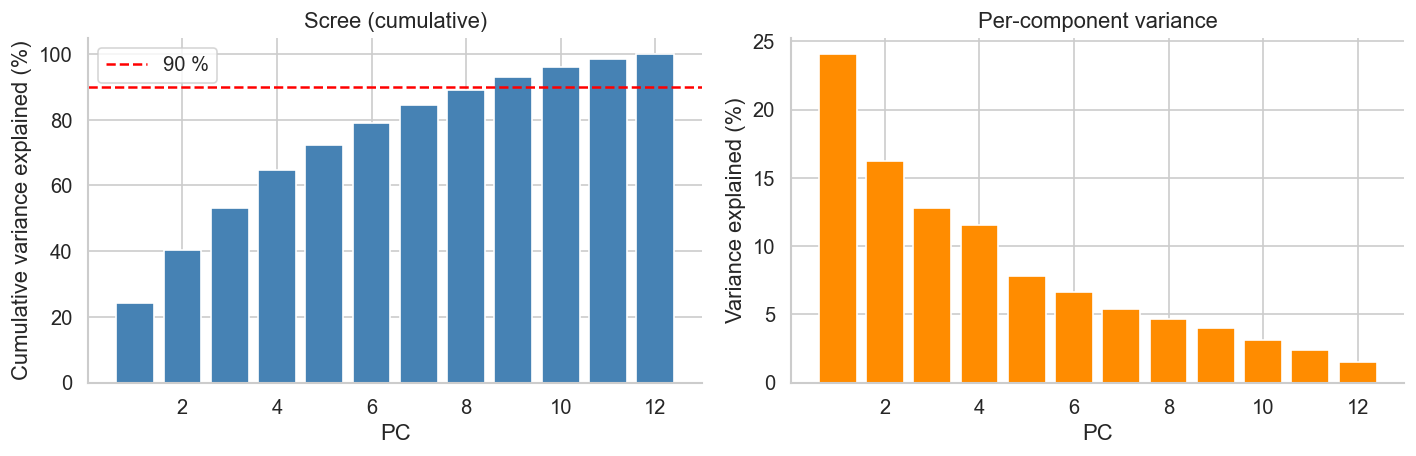

PC1 + PC2 explain 40.3% of variance


In [125]:
pca_data = df[PARAM_COLS + ["R_Squared"]].dropna()
X = StandardScaler().fit_transform(pca_data[PARAM_COLS])

pca = PCA()
pca.fit(X)
Z = pca.transform(X)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            np.cumsum(pca.explained_variance_ratio_) * 100,
            color="steelblue", edgecolor="white")
axes[0].axhline(90, color="red", linestyle="--", label="90 %")
axes[0].set_xlabel("PC")
axes[0].set_ylabel("Cumulative variance explained (%)")
axes[0].set_title("Scree (cumulative)")
axes[0].legend()

axes[1].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color="darkorange", edgecolor="white")
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Variance explained (%)")
axes[1].set_title("Per-component variance")

plt.tight_layout()
plt.show()
print(f"PC1 + PC2 explain {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of variance")

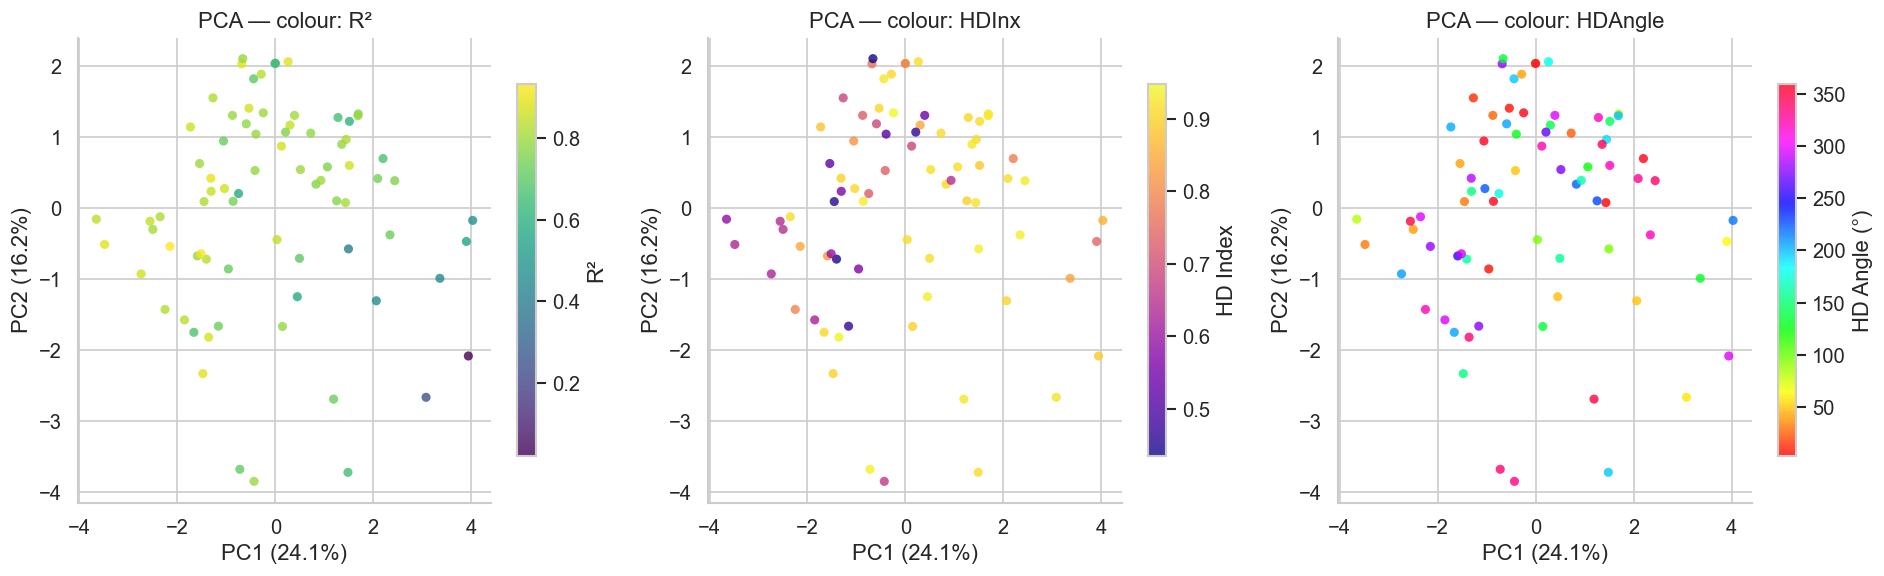

In [126]:
color_opts = {
    "R²":    (pca_data["R_Squared"].values,          "viridis", "R²"),
    "HDInx": (df.loc[pca_data.index, "HDInx"].values, "plasma",  "HD Index"),
    "HDAngle":(df.loc[pca_data.index, "HDAngle"].values,"hsv",   "HD Angle (°)"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, (c, cmap, cbar_label)) in zip(axes, color_opts.items()):
    valid = ~np.isnan(c)
    sc = ax.scatter(Z[valid, 0], Z[valid, 1], c=c[valid], cmap=cmap,
                    s=30, alpha=0.8, edgecolors="none")
    fig.colorbar(sc, ax=ax, label=cbar_label, shrink=0.8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"PCA — colour: {label}")

plt.tight_layout()
plt.show()

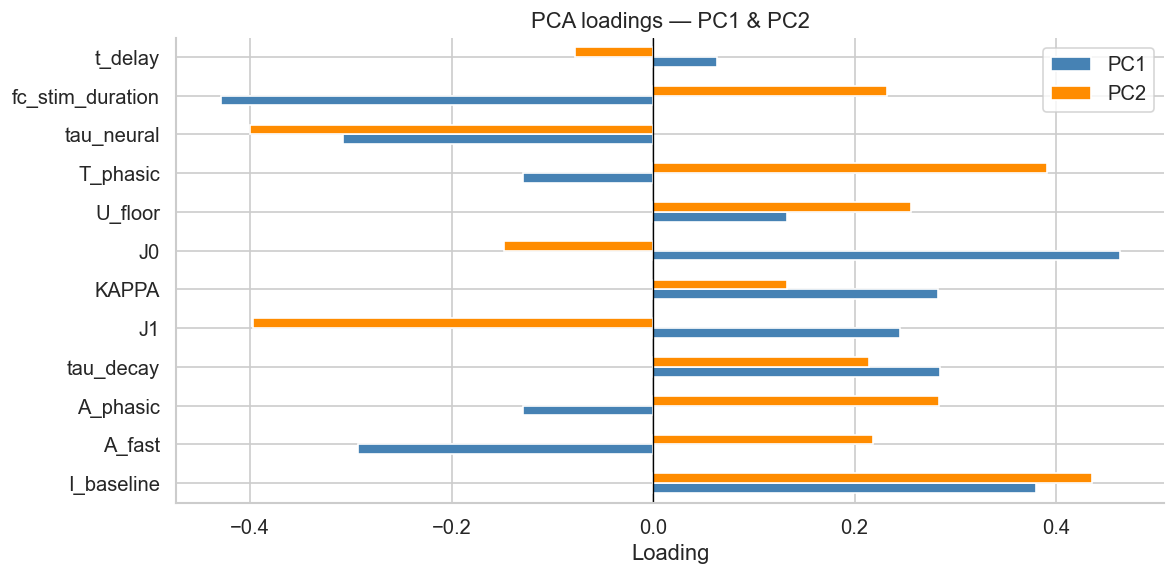

,PC1,PC2,PC3,PC4
I_baseline,0.380,0.436,0.014,0.002
A_fast,-0.293,0.218,-0.233,0.320
A_phasic,-0.129,0.284,-0.422,-0.286
tau_decay,0.285,0.214,-0.353,0.378
J1,0.245,-0.397,-0.146,0.347
KAPPA,0.283,0.133,0.398,0.426
J0,0.463,-0.148,-0.163,-0.111
U_floor,0.133,0.256,0.274,-0.372
T_phasic,-0.129,0.391,0.360,0.342
tau_neural,-0.307,-0.401,0.170,0.204


In [127]:
# Loadings biplot — which parameters drive each PC?
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=PARAM_COLS,
    columns=[f"PC{i+1}" for i in range(4)],
)

fig, ax = plt.subplots(figsize=(10, 5))
loadings[["PC1", "PC2"]].plot.barh(ax=ax, color=["steelblue", "darkorange"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("PCA loadings — PC1 & PC2")
ax.set_xlabel("Loading")
plt.tight_layout()
plt.show()
loadings.round(3)

## UMAP

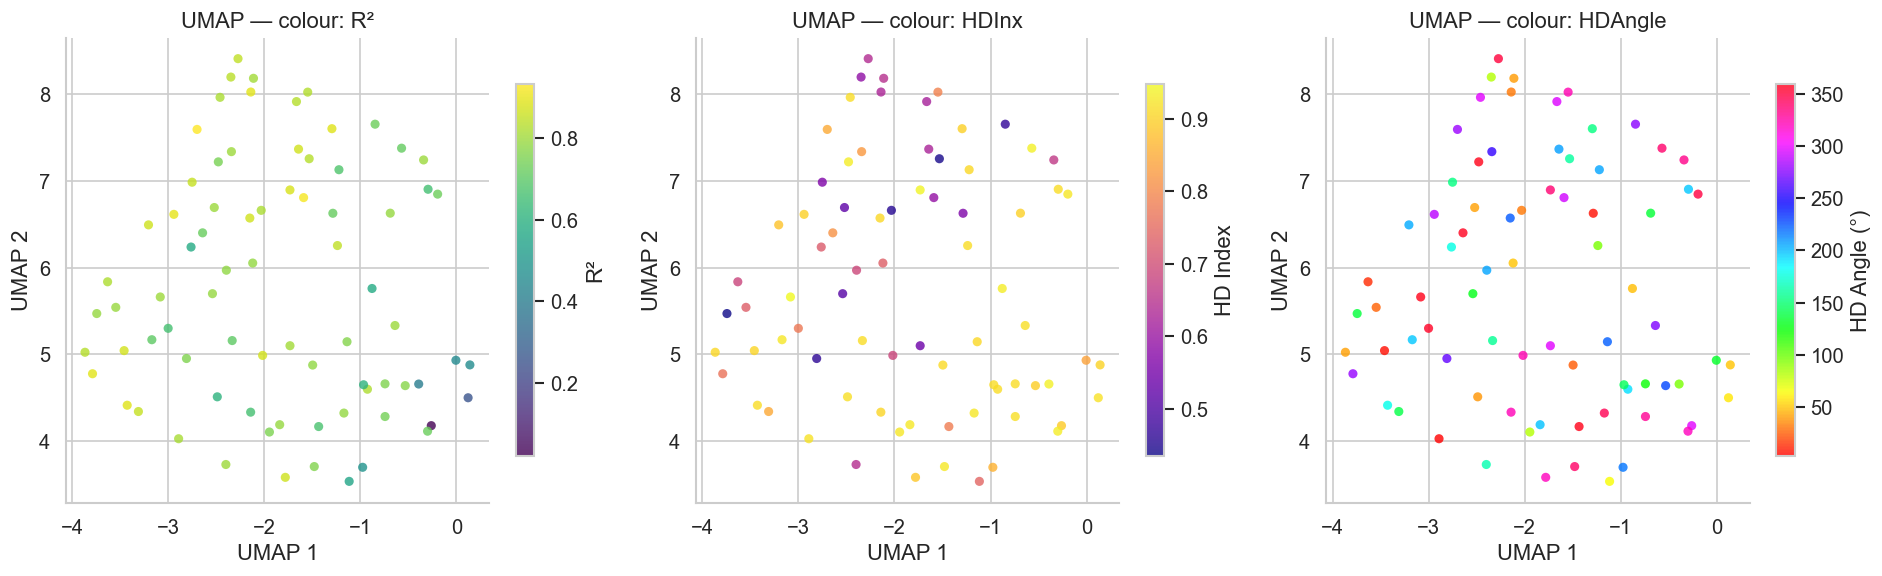

In [128]:
try:
    import umap

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    U = reducer.fit_transform(X)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (label, (c, cmap, cbar_label)) in zip(axes, color_opts.items()):
        valid = ~np.isnan(c)
        sc = ax.scatter(U[valid, 0], U[valid, 1], c=c[valid], cmap=cmap,
                        s=30, alpha=0.8, edgecolors="none")
        fig.colorbar(sc, ax=ax, label=cbar_label, shrink=0.8)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(f"UMAP — colour: {label}")

    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed. Run:  pip install umap-learn")

## Parameter vs biology scatter grid  
Top strongest correlators with R².

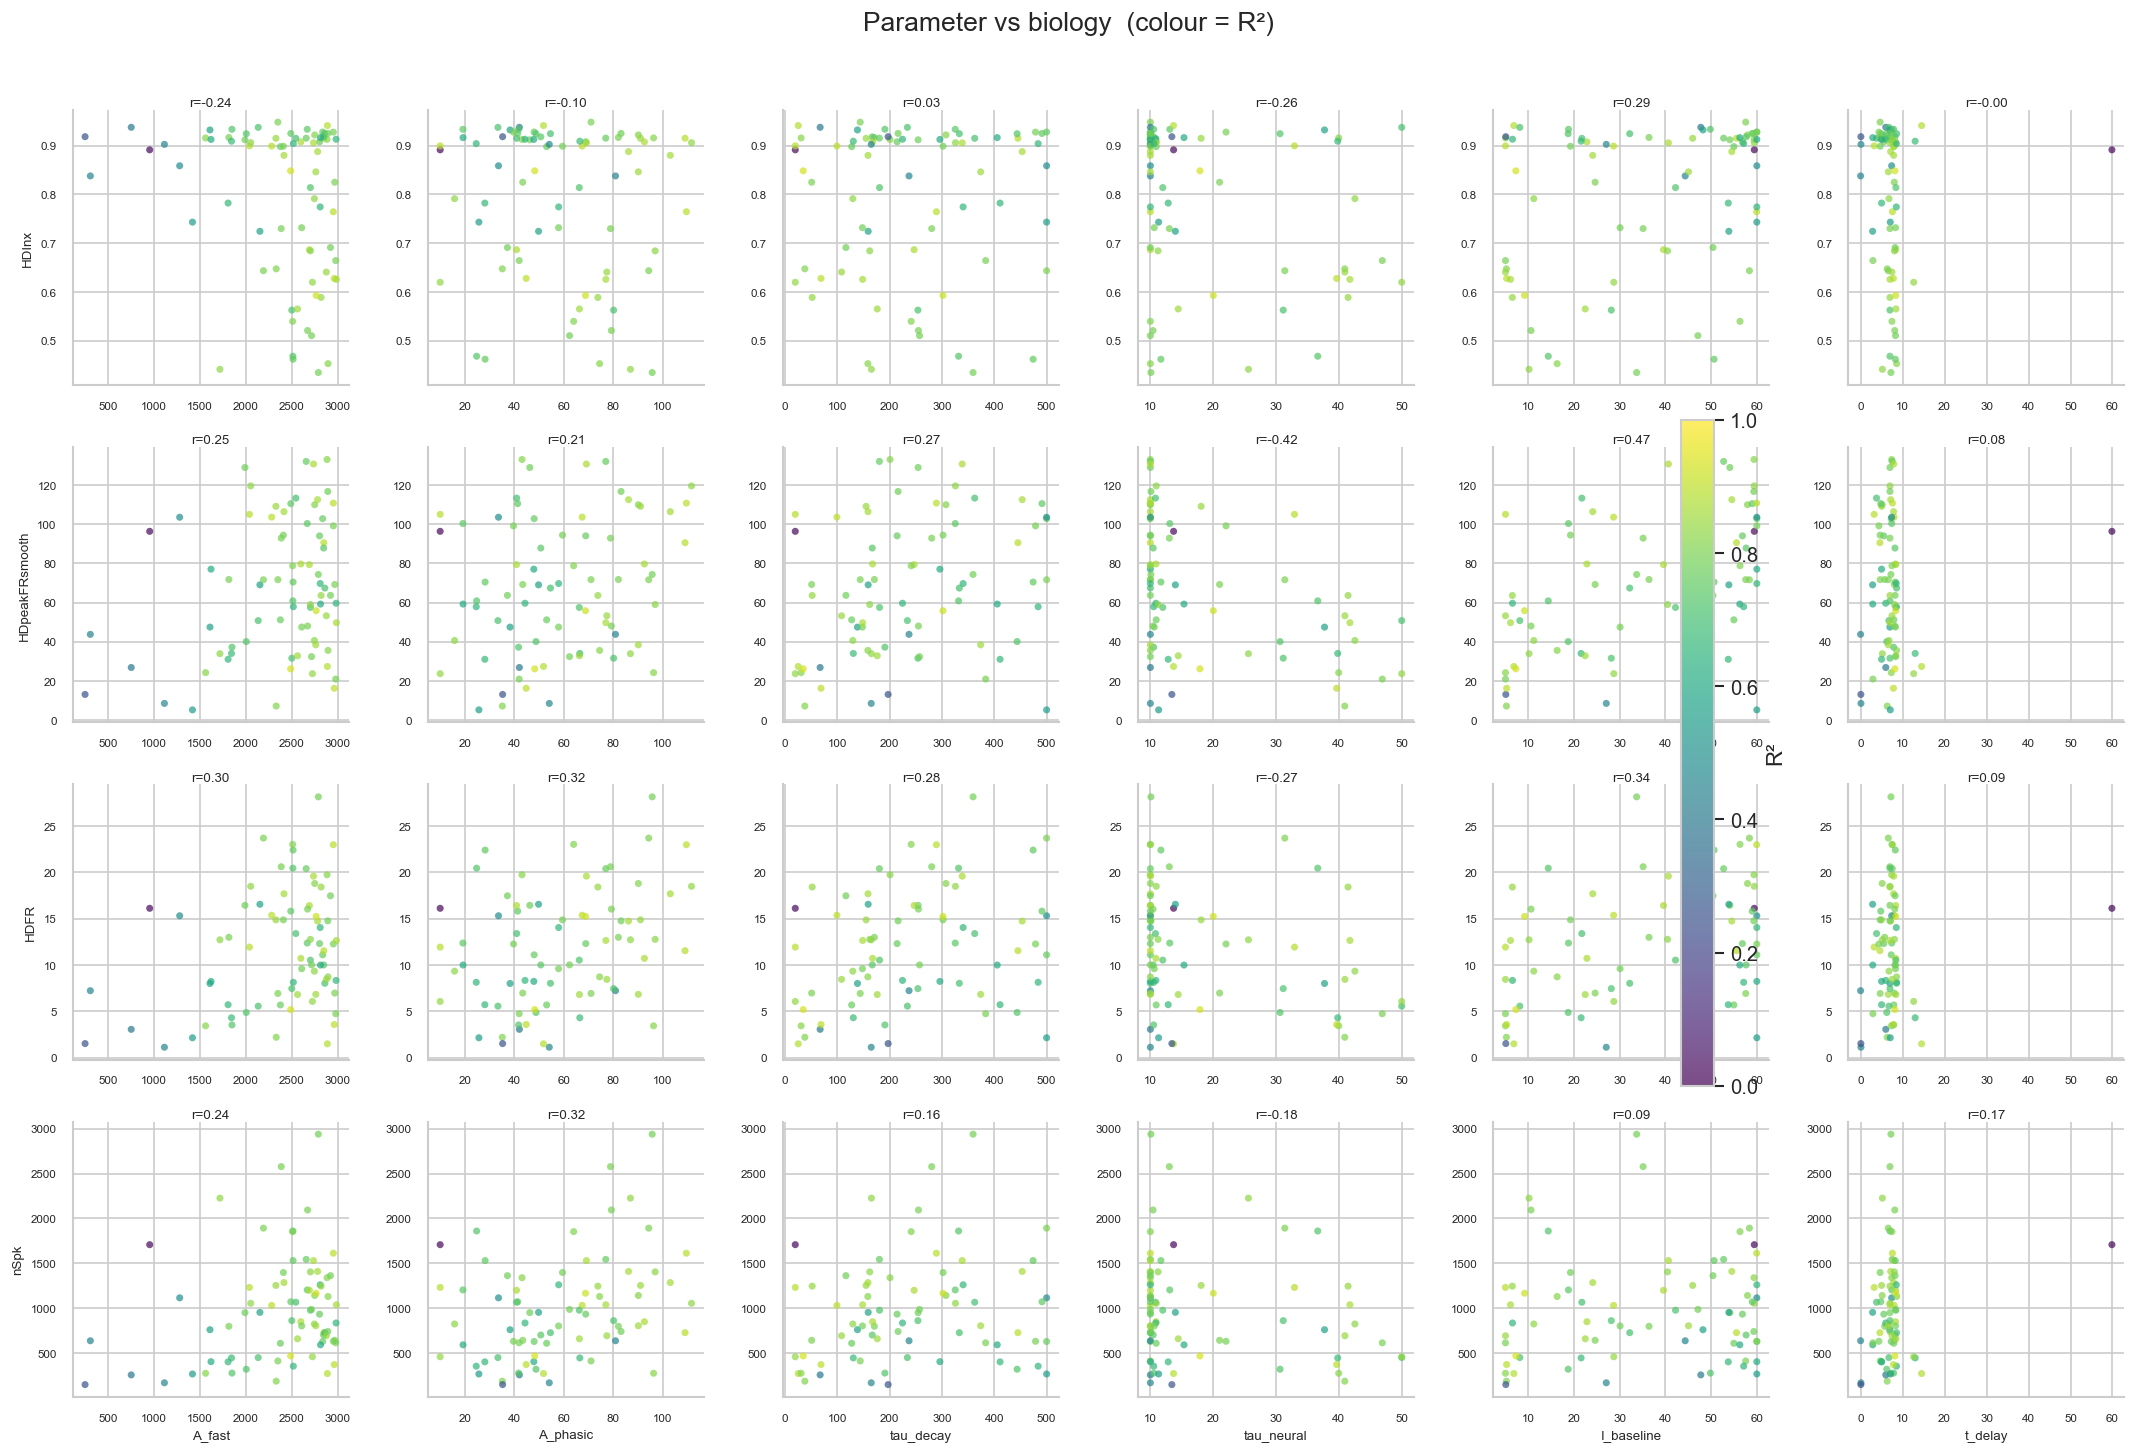

In [129]:
key_bio = [c for c in ["HDInx", "HDpeakFRsmooth", "HDFR", "nSpk"] if c in df.columns]
key_par = ["A_fast", "A_phasic", "tau_decay", "tau_neural", "I_baseline", "t_delay"]

fig, axes = plt.subplots(len(key_bio), len(key_par),
                         figsize=(len(key_par) * 3, len(key_bio) * 3))

for row_i, bio in enumerate(key_bio):
    for col_j, par in enumerate(key_par):
        ax  = axes[row_i, col_j]
        sub = df[[bio, par, "R_Squared"]].dropna()
        sc  = ax.scatter(sub[par], sub[bio], c=sub["R_Squared"],
                         cmap="viridis", s=18, alpha=0.7, edgecolors="none",
                         vmin=0, vmax=1)
        r   = sub[[par, bio]].corr().iloc[0, 1]
        ax.set_title(f"r={r:.2f}", fontsize=8, pad=2)
        if row_i == len(key_bio) - 1:
            ax.set_xlabel(par, fontsize=8)
        if col_j == 0:
            ax.set_ylabel(bio, fontsize=8)
        ax.tick_params(labelsize=7)

fig.colorbar(sc, ax=axes, label="R²", shrink=0.6, pad=0.02)
fig.suptitle("Parameter vs biology  (colour = R²)", y=1.01)
plt.tight_layout()
plt.show()

## PCA components vs biological metrics
PC scores for each cell plotted against biological variables — identifies which axis of parameter space maps onto biology.

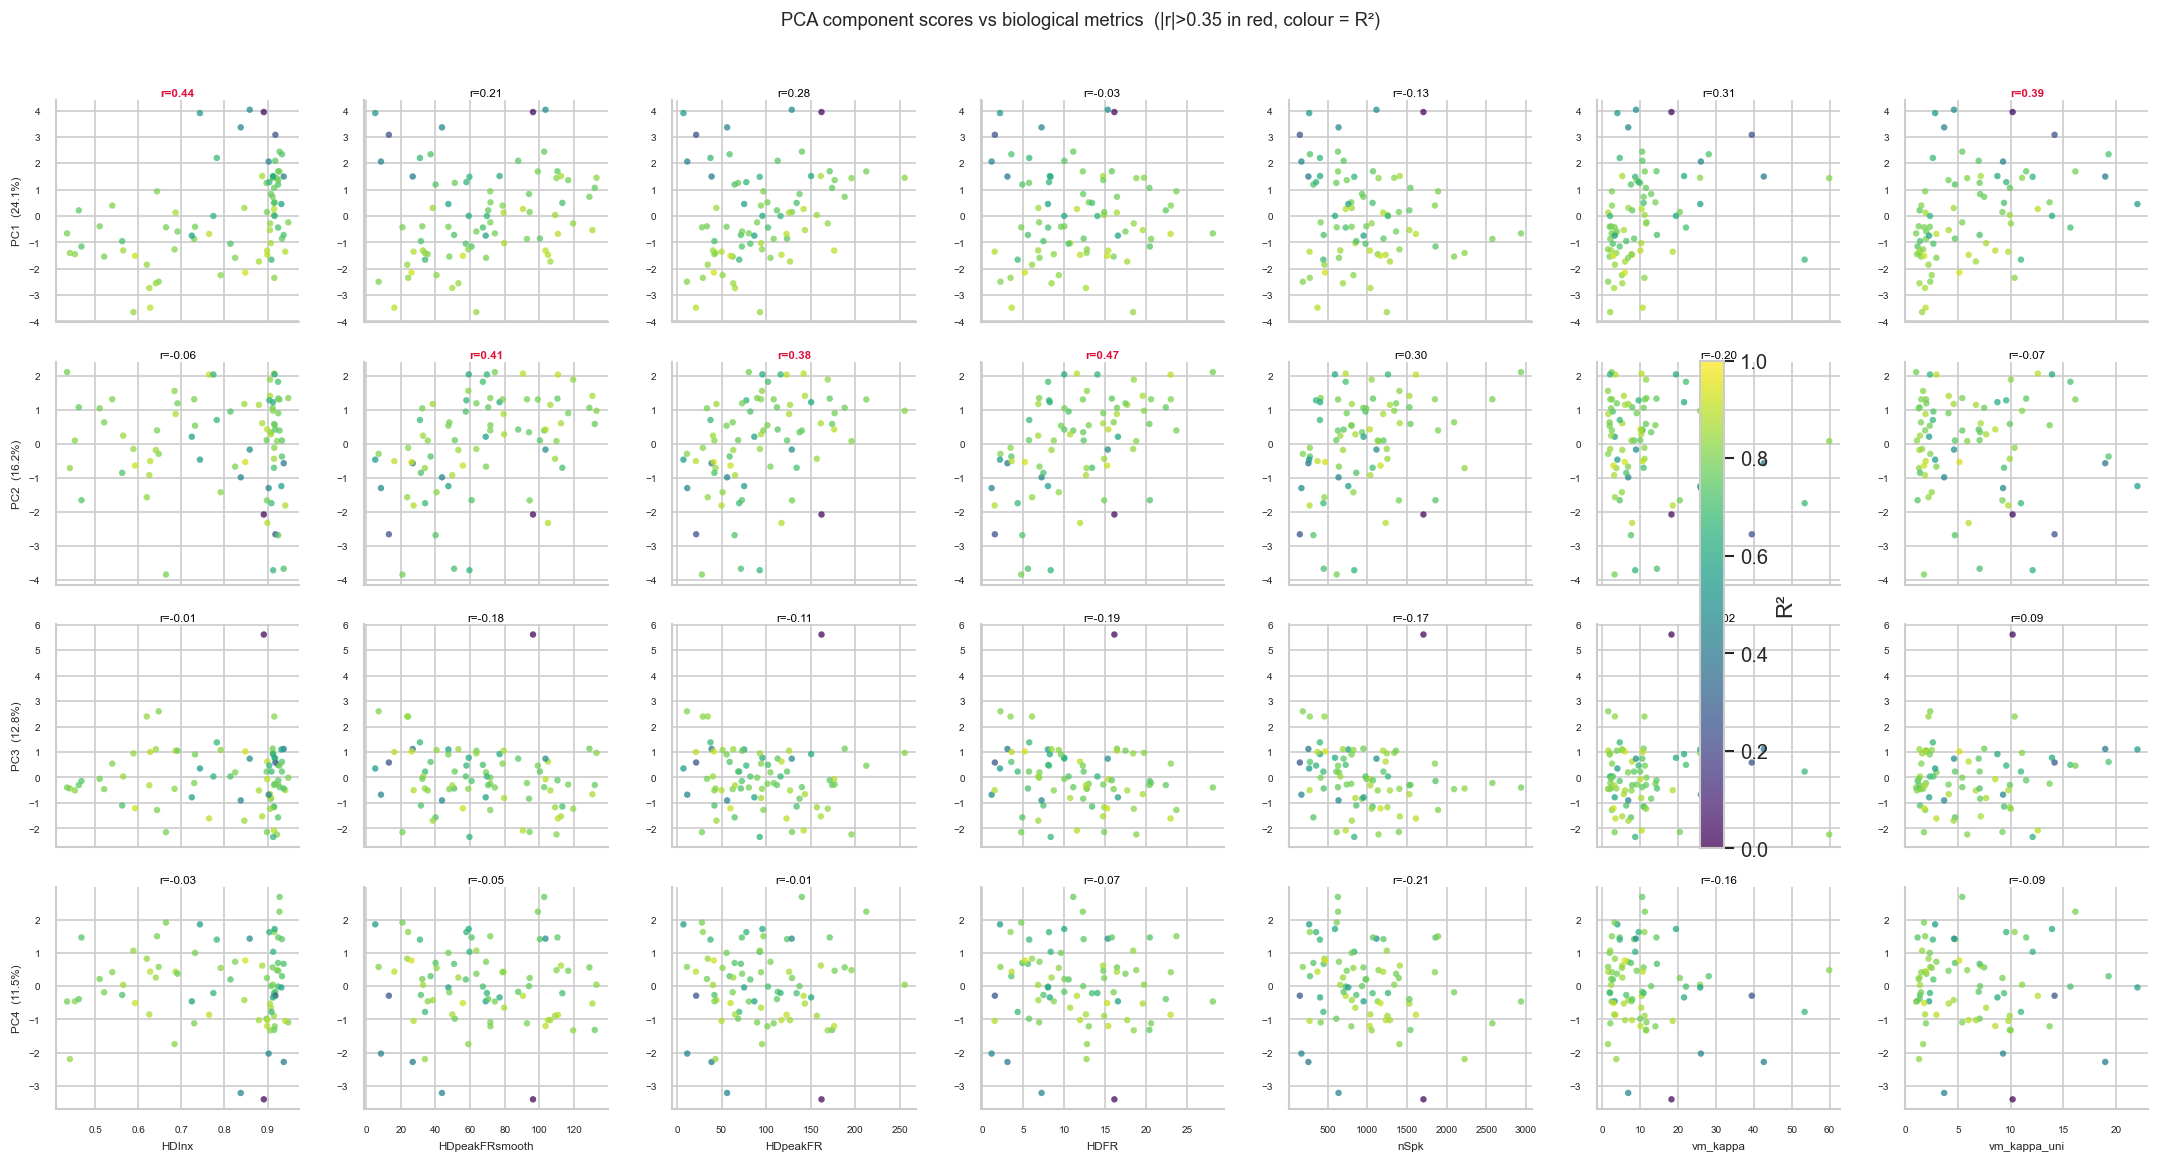

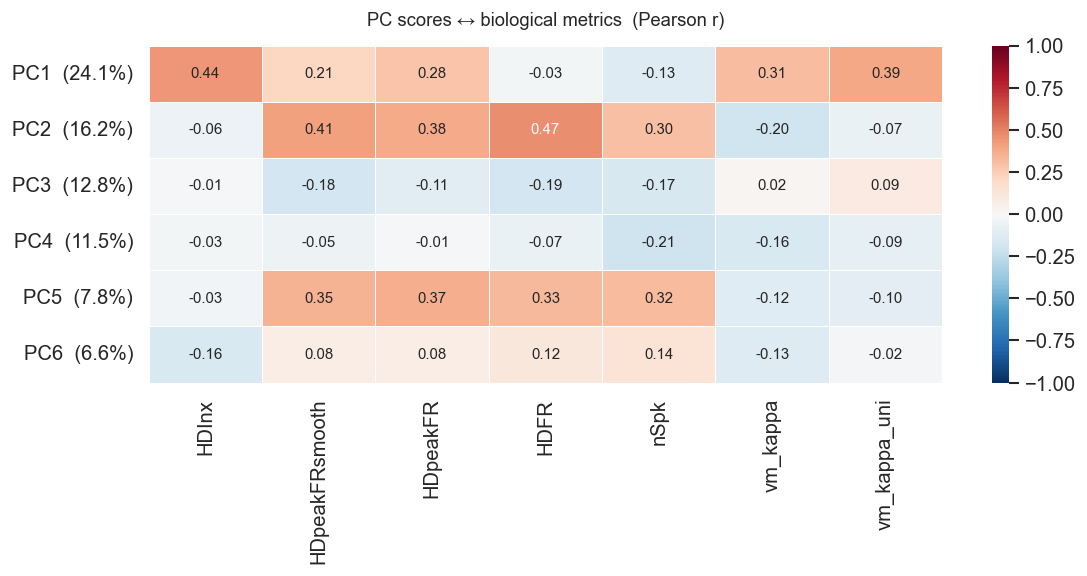

In [130]:
bio_pca_targets = [c for c in ["HDInx", "HDpeakFRsmooth", "HDpeakFR",
                                "HDFR", "nSpk", "vm_kappa", "vm_kappa_uni"]
                   if c in df.columns]
N_PCS  = 4
N_BIOS = len(bio_pca_targets)

# ── scatter grid: PC1..PC4 × bio metrics ─────────────────────────────────
fig, axes = plt.subplots(N_PCS, N_BIOS,
                          figsize=(N_BIOS * 2.6, N_PCS * 2.4),
                          sharex="col")

r_matrix = np.full((N_PCS, N_BIOS), np.nan)

for pc_i in range(N_PCS):
    pc_scores = Z[:, pc_i]
    for bio_j, bio in enumerate(bio_pca_targets):
        ax       = axes[pc_i, bio_j]
        bio_vals = df.loc[pca_data.index, bio].values.astype(float)
        valid    = np.isfinite(pc_scores) & np.isfinite(bio_vals)

        sc = ax.scatter(bio_vals[valid], pc_scores[valid],
                        c=pca_data["R_Squared"].values[valid],
                        cmap="viridis", s=15, alpha=0.75, edgecolors="none",
                        vmin=0, vmax=1)
        r = float(np.corrcoef(bio_vals[valid], pc_scores[valid])[0, 1]) if valid.sum() > 3 else np.nan
        r_matrix[pc_i, bio_j] = r
        ax.set_title(f"r={r:.2f}", fontsize=7, pad=2,
                     color="crimson" if abs(r) > 0.35 else "black",
                     fontweight="bold" if abs(r) > 0.35 else "normal")
        if pc_i == N_PCS - 1:
            ax.set_xlabel(bio, fontsize=7)
        if bio_j == 0:
            var_pct = pca.explained_variance_ratio_[pc_i] * 100
            ax.set_ylabel(f"PC{pc_i+1}  ({var_pct:.1f}%)", fontsize=7)
        ax.tick_params(labelsize=6)

fig.colorbar(sc, ax=axes, label="R²", shrink=0.55, pad=0.02)
fig.suptitle("PCA component scores vs biological metrics  (|r|>0.35 in red, colour = R²)",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

# ── correlation heatmap: PC1..PC6 × bio metrics ───────────────────────────
pc_df   = pd.DataFrame(Z[:, :6], index=pca_data.index,
                        columns=[f"PC{i+1}" for i in range(6)])
bio_df  = df.loc[pca_data.index, bio_pca_targets].replace([np.inf, -np.inf], np.nan)
combined = pd.concat([pc_df, bio_df], axis=1)
pc_bio_corr = combined.corr().loc[
    [f"PC{i+1}" for i in range(6)],
    bio_pca_targets,
]

# annotate with variance explained in row labels
row_labels = [
    f"PC{i+1}  ({pca.explained_variance_ratio_[i]*100:.1f}%)" for i in range(6)
]
pc_bio_corr.index = row_labels

fig, ax = plt.subplots(figsize=(max(8, N_BIOS * 1.4), 5))
sns.heatmap(pc_bio_corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={"size": 9}, ax=ax)
ax.set_title("PC scores ↔ biological metrics  (Pearson r)", pad=12, fontsize=11)
plt.tight_layout()
plt.show()

## Von Mises analysis — unimodal vs bimodal tuning
`vm_deltaBIC > 0` → bimodal model fits better than unimodal.

Bimodal: 67  |  Unimodal: 10


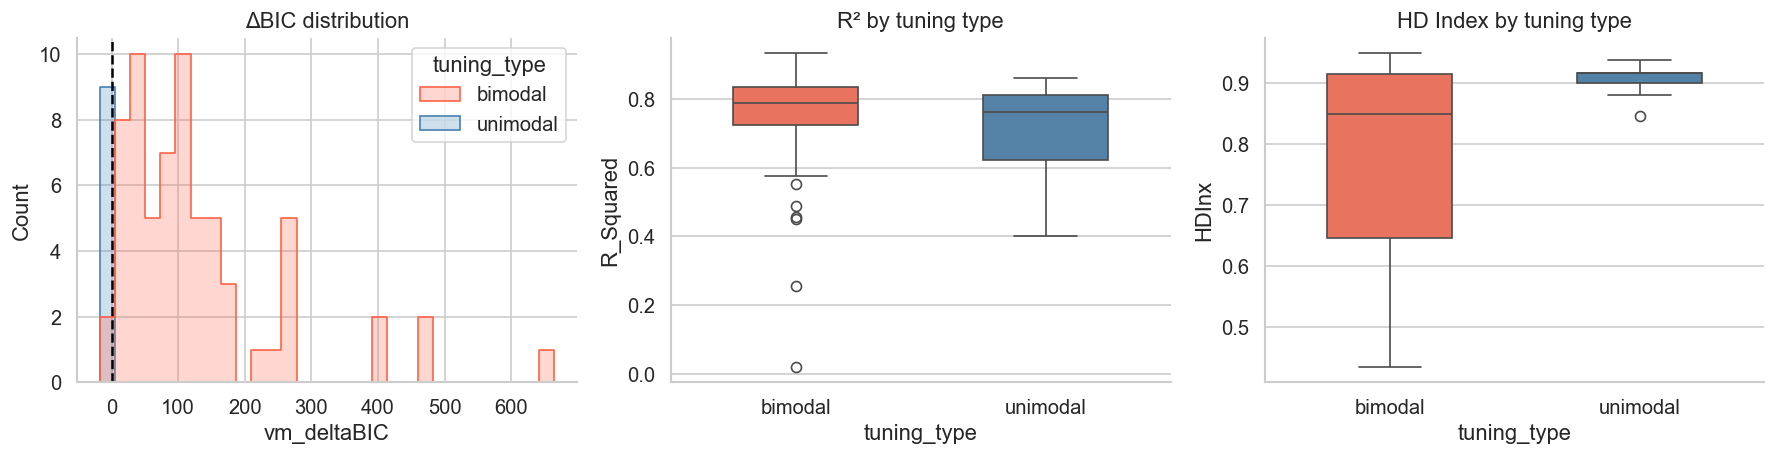

In [131]:
if "vm_deltaBIC" not in df.columns or df["vm_deltaBIC"].notna().sum() < 5:
    print("vm_deltaBIC not available / too few values.")
else:
    vm_sub = df.dropna(subset=["vm_deltaBIC"])
    vm_sub = vm_sub.assign(tuning_type=np.where(vm_sub["vm_deltaBIC"] > 0, "bimodal", "unimodal"))

    n_bi  = (vm_sub["tuning_type"] == "bimodal").sum()
    n_uni = (vm_sub["tuning_type"] == "unimodal").sum()
    print(f"Bimodal: {n_bi}  |  Unimodal: {n_uni}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    palette = {"bimodal": "tomato", "unimodal": "steelblue"}

    sns.histplot(data=vm_sub, x="vm_deltaBIC", hue="tuning_type",
                 bins=30, palette=palette, ax=axes[0], element="step")
    axes[0].axvline(0, color="black", linestyle="--")
    axes[0].set_title("ΔBIC distribution")

    sns.boxplot(data=vm_sub, x="tuning_type", y="R_Squared",
                palette=palette, ax=axes[1], width=0.5)
    axes[1].set_title("R² by tuning type")

    sns.boxplot(data=vm_sub, x="tuning_type", y="HDInx",
                palette=palette, ax=axes[2], width=0.5)
    axes[2].set_title("HD Index by tuning type")

    plt.tight_layout()
    plt.show()

## Top-ranked cells by R²

In [132]:
top = df.sort_values("R_Squared", ascending=False).head(20)
display_cols = ["Animal_Id", "Cell_Id", "R_Squared", "Loss_360N",
                "HDInx", "HDpeakFRsmooth", "HDFR", "HDAngle"]
display_cols = [c for c in display_cols if c in top.columns]

top[display_cols].style.background_gradient(subset=["R_Squared"], cmap="Greens").format({
    "R_Squared": "{:.3f}",
    "Loss_360N": "{:.2f}",
    "HDInx":     "{:.3f}",
    "HDpeakFRsmooth": "{:.1f}",
    "HDFR":      "{:.1f}",
    "HDAngle":   "{:.1f}",
})

,Animal_Id,Cell_Id,R_Squared,Loss_360N,HDInx,HDpeakFRsmooth,HDFR,HDAngle
69,EB20,157.000000,0.933,28.73,0.848,26.2,5.2,280.7
76,EB20,173.000000,0.920,20.27,0.593,55.8,15.2,293.0
20,EB12,70.000000,0.894,29.93,0.899,103.6,15.4,287.3
57,EB18,120.000000,0.892,36.62,0.628,16.3,3.6,32.0
51,EB18,111.000000,0.891,66.44,0.764,110.7,23.0,279.9
17,EB12,67.000000,0.890,20.69,0.899,105.0,11.9,154.7
3,EB12,52.000000,0.890,15.26,0.915,90.5,11.5,179.5
25,EB12,76.000000,0.879,9.29,0.941,27.4,1.5,337.1
22,EB12,72.000000,0.870,30.36,0.906,130.7,19.6,5.9
48,EB18,105.000000,0.870,80.22,0.686,79.3,16.4,322.3


## Fit mosaic — model overlay on biological trace
Re-runs the optimized model for each cell and overlays it on the cell's PSTH.

In [133]:
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from workbench.data.load_ad_table import load, stim_rows

# ── model constants (mirror DoVM_model_slurm.py) ─────────────────────────
_N = 360
_THETA = np.linspace(-np.pi, np.pi, _N, endpoint=False)
_SIGMA_PHASIC = 10
_DT = 0.2
_T_BURN_IN = -300
_T_END = 1000
_TIME = np.arange(_T_BURN_IN, _T_END, _DT)
_T_STIM = 100
_COS_D_THETA = np.cos(np.angle(np.exp(1j * (_THETA[:, None] - _THETA[None, :]))))
_IDX_0 = np.argmin(np.abs(_THETA))

SPEAKER_POSITION = {"a": 93, "w": 178, "e": 272, "r": 356}
SPEAKERS         = ["a", "w", "e", "r"]
HALF_WINDOW      = 1500
TIME_BIN         = 0.006
NBINS            = int(np.round(HALF_WINDOW / (TIME_BIN * 1000)))
RASTER_EDGES     = np.linspace(-HALF_WINDOW, HALF_WINDOW, NBINS * 2 + 1)
_centers         = np.median(np.vstack([RASTER_EDGES[:-1], RASTER_EDGES[1:]]), axis=0)
BINS_PLOT        = np.concatenate([[RASTER_EDGES[0]], _centers])[1:]
WIN_LO, WIN_HI   = -100, 600
SMOOTH_SIGMA     = 3


def _run_model(params: dict) -> tuple[np.ndarray, np.ndarray]:
    """Run N=360 model; return (t_rel, pd_trace)."""
    N   = _N
    W   = (params["J1"] * np.exp(params["KAPPA"] * (_COS_D_THETA - 1.0)) - params["J0"]) / N
    u   = 40.0 * np.maximum(0, np.cos(_THETA))
    r   = np.maximum(0, u)
    rates = np.zeros((len(_TIME), N))
    sigma_rad = np.deg2rad(_SIGMA_PHASIC)
    fc_end    = _T_STIM + params["fc_stim_duration"]

    for step, t in enumerate(_TIME):
        I_ext = np.ones(N) * params["I_baseline"]
        if _T_STIM <= t < fc_end:
            I_ext += params["A_fast"]
        elif t >= params["T_phasic"]:
            decay = np.exp(-(t - params["T_phasic"]) / params["tau_decay"])
            I_ext += params["A_phasic"] * decay * np.exp(-0.5 * (_THETA / sigma_rad) ** 2)
        u += (-u + W @ r + I_ext) * (_DT / params["tau_neural"])
        u  = np.maximum(params["U_floor"], u)
        r  = np.maximum(0, u)
        rates[step] = r

    mask = _TIME >= 0
    return _TIME[mask] - _T_STIM, rates[mask, _IDX_0]


def _cell_psth(stim_row, hd_angle: float) -> np.ndarray:
    """Reconstruct per-cell PSTH from RasterTimes/RasterRows."""
    rt = stim_row["RasterTimes"]
    rr = stim_row["RasterRows"]

    if isinstance(rt, dict):
        valid_spk = [k for k in SPEAKERS if k in rt]
        speaker_angles = np.array([SPEAKER_POSITION[k] for k in valid_spk])
        diff    = hd_angle - speaker_angles
        wrapped = (diff + 180) % 360 - 180
        closest = valid_spk[int(np.argmin(np.abs(wrapped)))]
        times, rows_arr = rt[closest], rr[closest]
    else:
        times    = np.asarray(rt).flatten()
        rows_arr = np.asarray(rr).flatten()

    times    = np.asarray(times).flatten()
    rows_arr = np.asarray(rows_arr).flatten()
    n_trials = int(np.max(rows_arr)) if rows_arr.size > 0 else 0
    if n_trials == 0 or times.size == 0:
        return np.zeros(len(RASTER_EDGES) - 1)
    counts, _ = np.histogram(times, bins=RASTER_EDGES)
    return counts / (n_trials * TIME_BIN)


# ── load AD table once ────────────────────────────────────────────────────
print("Loading AD table…")
_ad   = load(r"\\172.25.250.112\burgalossi\lab_share\Data\Florian\HD-model\AD_combined_table.mat")
_sr   = stim_rows(_ad.df)
_stim_lookup = {
    (str(row["Animal_Id"]), str(int(float(row["Cell_Id"])))):
        row for _, row in _sr.iterrows()
}
print(f"Stim rows indexed: {len(_stim_lookup)}")

Loading AD table…
Stim rows indexed: 156


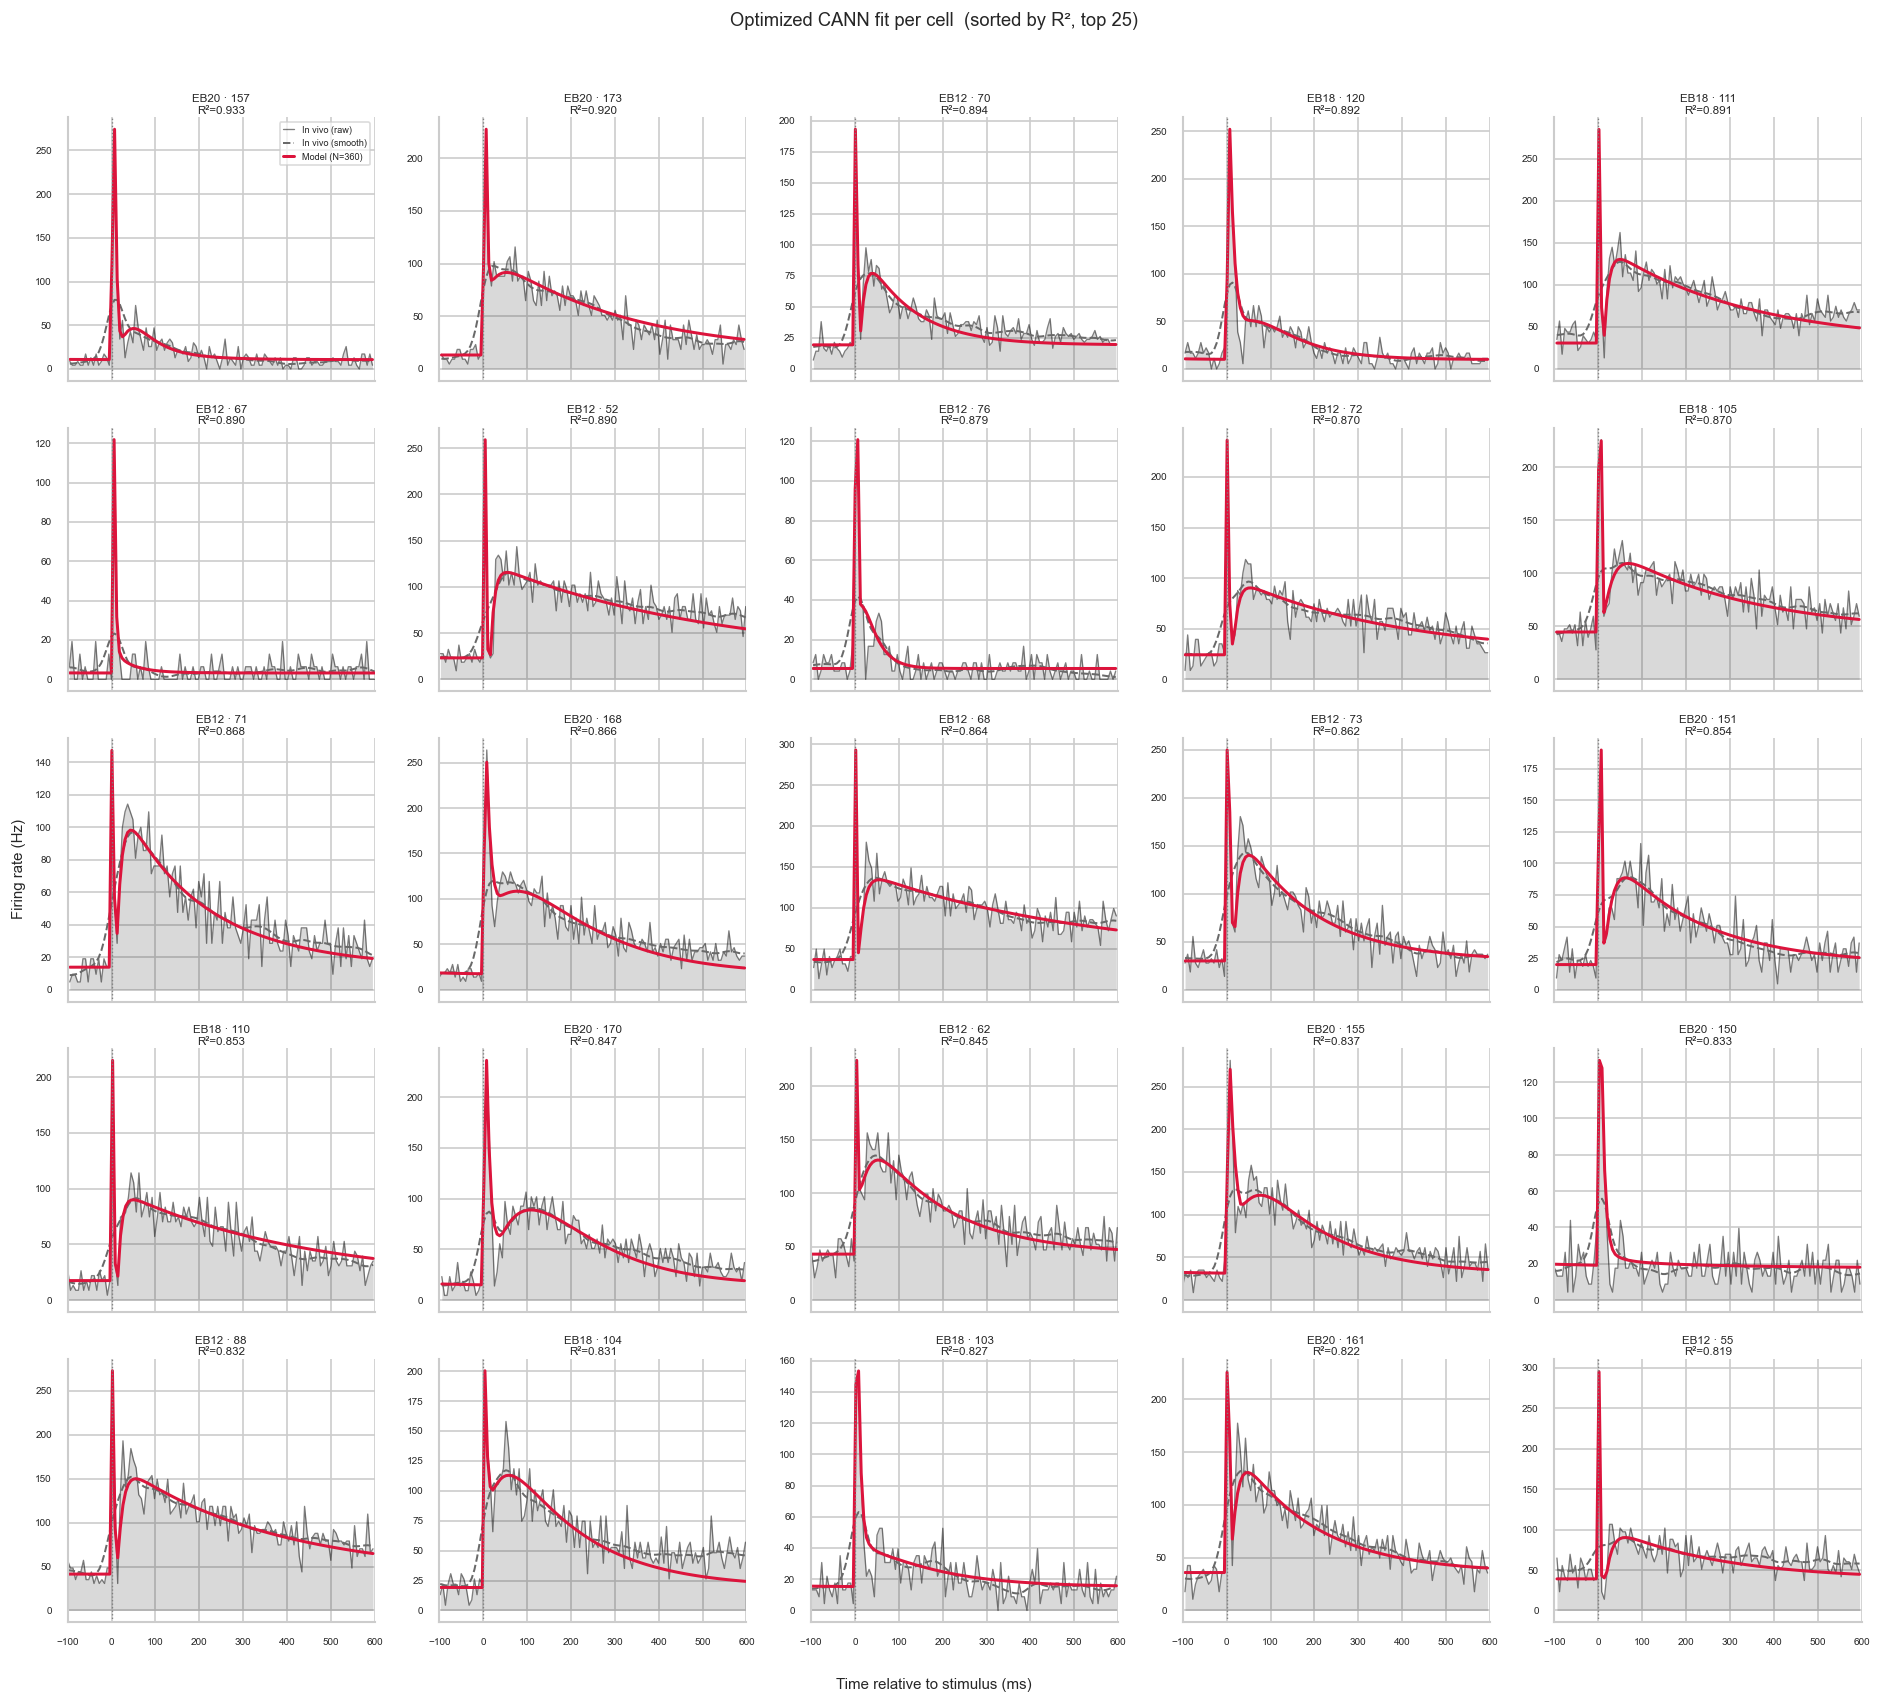

In [134]:
# ── tuneable ──────────────────────────────────────────────────────────────
N_CELLS   = 25       # cells to show (best R² first); set to None for all
MIN_R2    = 0.0      # skip cells below this threshold
NCOLS     = 5        # grid columns
# ─────────────────────────────────────────────────────────────────────────

param_names = [
    "I_baseline", "A_fast", "A_phasic", "tau_decay",
    "J1", "KAPPA", "J0", "U_floor",
    "T_phasic", "tau_neural", "fc_stim_duration", "t_delay",
]

pool = df[df["R_Squared"] >= MIN_R2].sort_values("R_Squared", ascending=False)
if N_CELLS is not None:
    pool = pool.head(N_CELLS)

nrows = int(np.ceil(len(pool) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS,
                         figsize=(NCOLS * 3.2, nrows * 2.8),
                         sharex=True)
axes = np.array(axes).reshape(-1)  # always 1-D

for ax_i, (_, row) in enumerate(pool.iterrows()):
    ax   = axes[ax_i]
    aid  = str(row["Animal_Id"])
    cid  = str(int(float(row["Cell_Id"])))
    key  = (aid, cid)
    r2   = row["R_Squared"]

    params = {p: row[p] for p in param_names}
    t_delay = params.pop("t_delay")

    # ── biological PSTH ──────────────────────────────────────────────
    if key in _stim_lookup:
        hd_angle = float(row["HDAngle"]) if "HDAngle" in row and pd.notna(row["HDAngle"]) else 0.0
        raw_psth = _cell_psth(_stim_lookup[key], hd_angle)
        smooth   = gaussian_filter1d(raw_psth.astype(float), sigma=SMOOTH_SIGMA)

        t_vivo   = BINS_PLOT - t_delay
        vmask    = (t_vivo >= WIN_LO) & (t_vivo <= WIN_HI)

        ax.fill_between(t_vivo[vmask], raw_psth[vmask],
                        color="black", alpha=0.15, linewidth=0)
        ax.plot(t_vivo[vmask], raw_psth[vmask],
                color="black", lw=0.8, alpha=0.5, label="In vivo (raw)")
        ax.plot(t_vivo[vmask], smooth[vmask],
                color="dimgray", lw=1.2, linestyle="--", label="Smoothed")
    else:
        vmask = np.zeros(len(BINS_PLOT), dtype=bool)  # no data
        ax.text(0.5, 0.5, "no PSTH", transform=ax.transAxes,
                ha="center", va="center", color="gray", fontsize=7)

    # ── model trace ──────────────────────────────────────────────────
    try:
        t_model, pd_trace = _run_model(params)
        mmask   = (t_model >= WIN_LO) & (t_model <= WIN_HI)
        if vmask.any():
            interp_fn    = interp1d(t_model[mmask], pd_trace[mmask],
                                    bounds_error=False, fill_value="extrapolate")
            model_at_vivo = interp_fn(t_vivo[vmask])
            ax.plot(t_vivo[vmask], model_at_vivo,
                    color="crimson", lw=1.8, label="Model (N=360)")
        else:
            ax.plot(t_model[mmask], pd_trace[mmask],
                    color="crimson", lw=1.8, label="Model (N=360)")
    except Exception as e:
        ax.text(0.5, 0.3, f"err: {e}", transform=ax.transAxes,
                ha="center", va="center", color="red", fontsize=6)

    ax.axvline(0, color="gray", linestyle=":", lw=0.8)
    ax.set_xlim(WIN_LO, WIN_HI)
    ax.set_title(f"{aid} · {cid}\nR²={r2:.3f}", fontsize=7, pad=2)
    ax.tick_params(labelsize=6)
    ax.set_xlabel("")

# ── shared labels ─────────────────────────────────────────────────────────
for ax in axes[len(pool):]:
    ax.set_visible(False)

# one shared legend in first panel
handles = [
    plt.Line2D([0], [0], color="black",   lw=0.8, alpha=0.5, label="In vivo (raw)"),
    plt.Line2D([0], [0], color="dimgray", lw=1.2, linestyle="--", label="In vivo (smooth)"),
    plt.Line2D([0], [0], color="crimson", lw=1.8, label="Model (N=360)"),
]
axes[0].legend(handles=handles, fontsize=5.5, loc="upper right",
               framealpha=0.7, handlelength=1.2)

fig.supxlabel("Time relative to stimulus (ms)", fontsize=9)
fig.supylabel("Firing rate (Hz)", fontsize=9)
fig.suptitle(
    f"Optimized CANN fit per cell  (sorted by R², top {len(pool)})",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

## Fit mosaic — worst 25 cells by R²
Same overlay sorted ascending by R² to inspect failure modes.

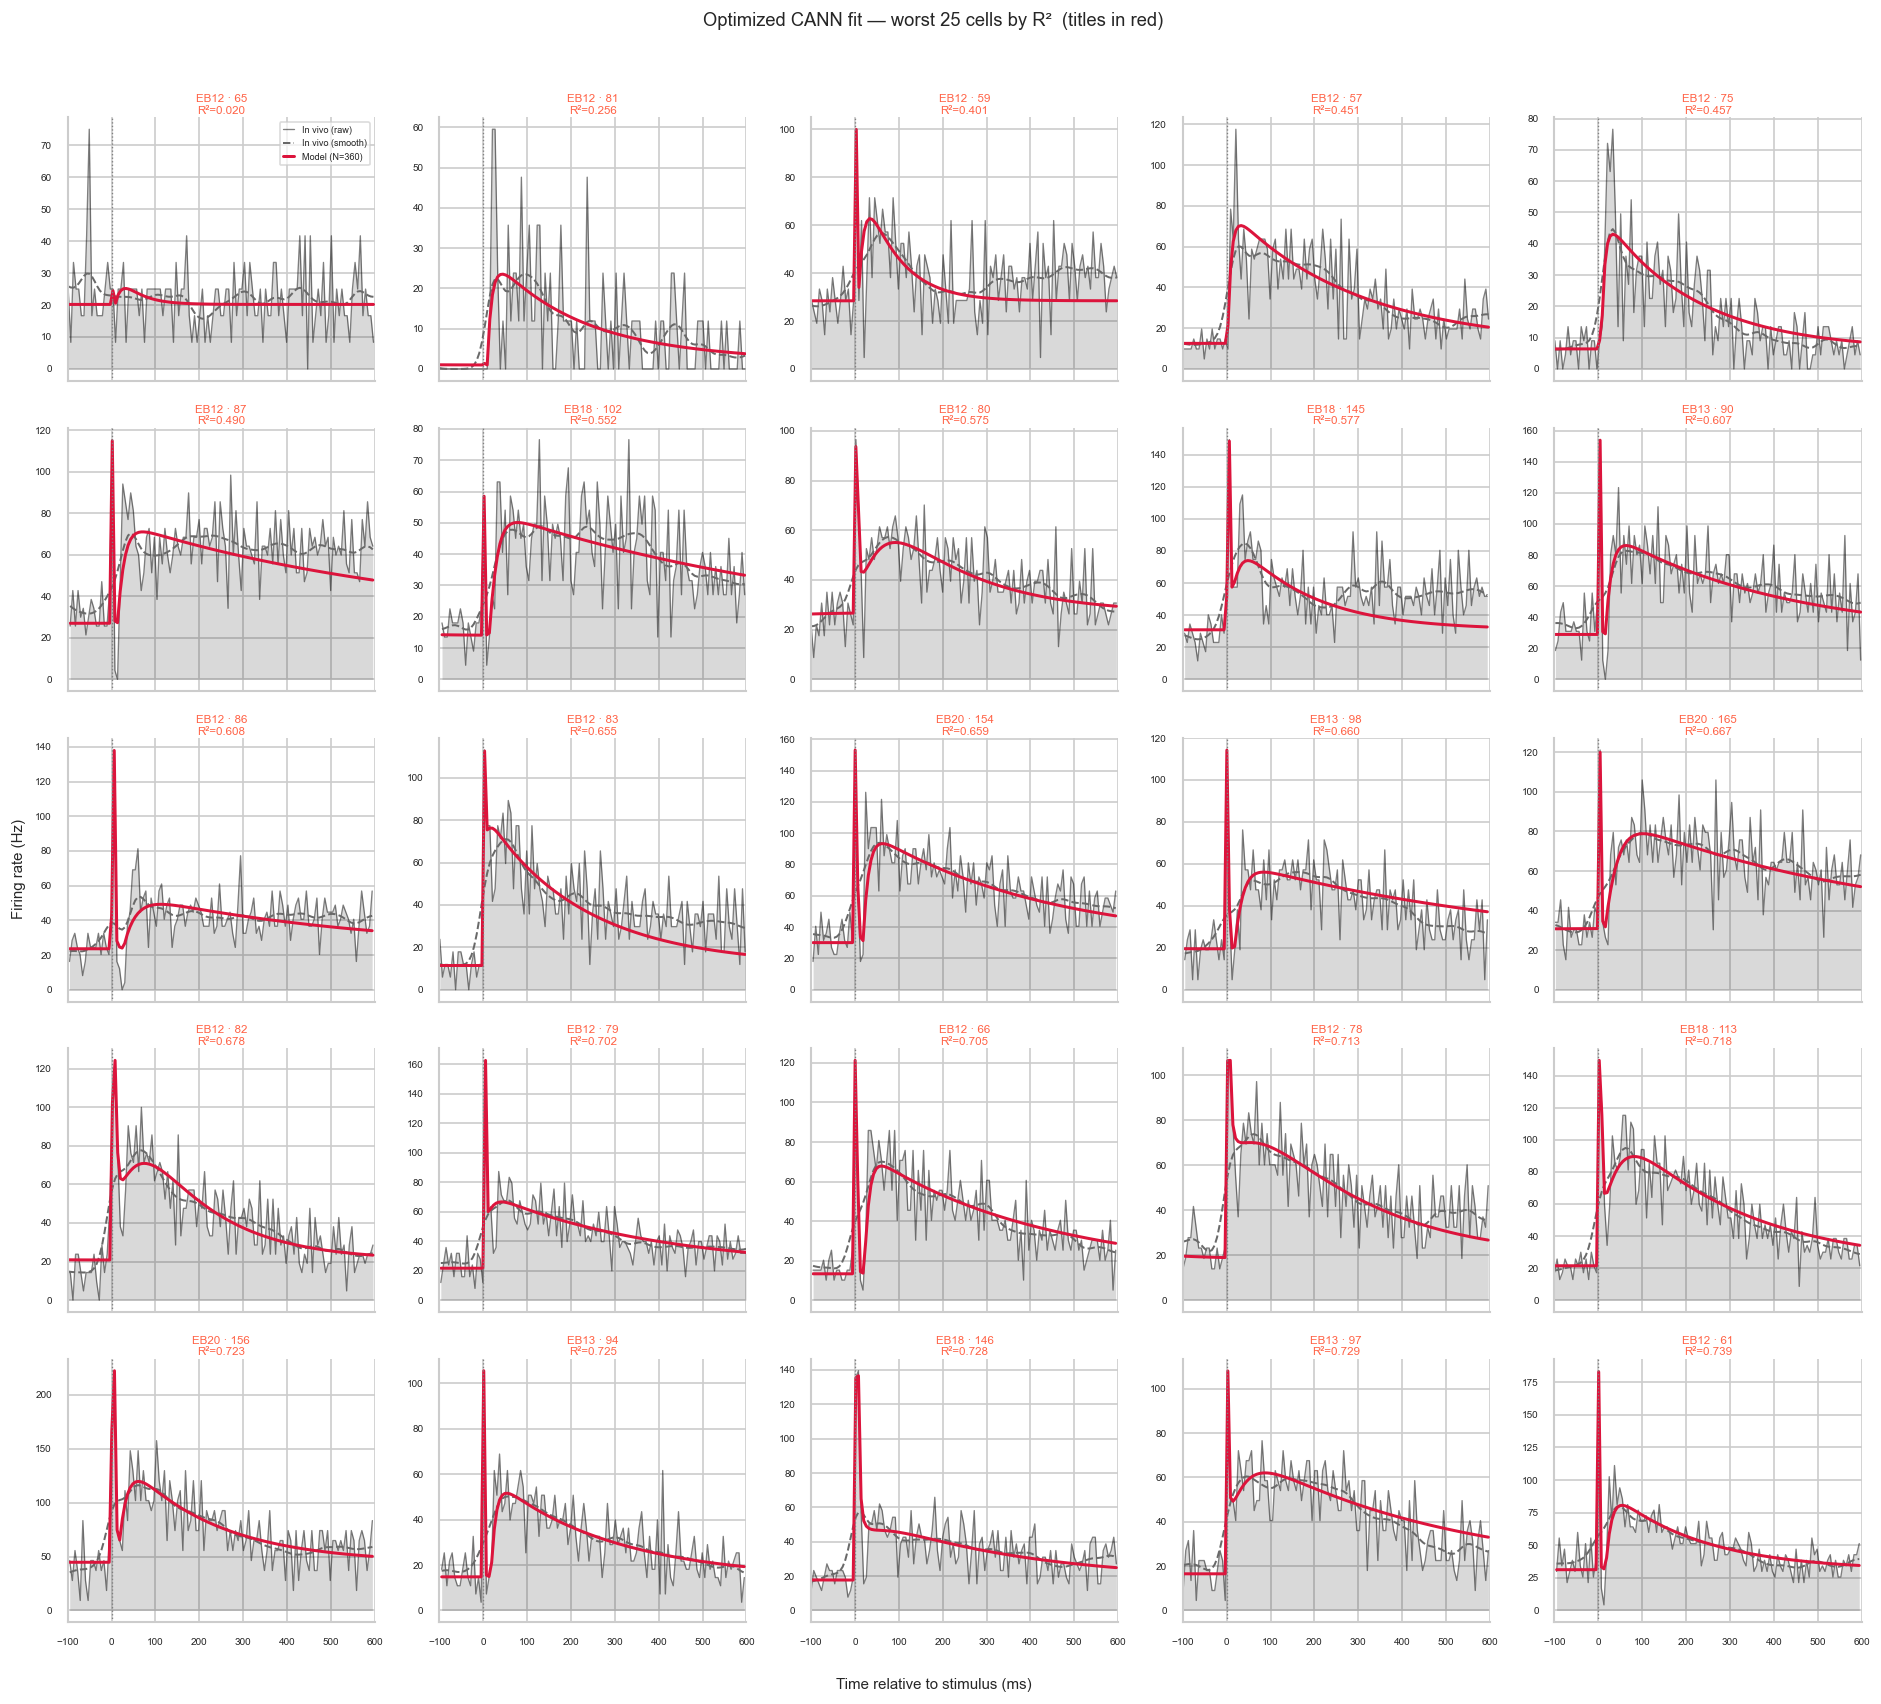

In [135]:
N_WORST   = 25
NCOLS_W   = 5

param_names = [
    "I_baseline", "A_fast", "A_phasic", "tau_decay",
    "J1", "KAPPA", "J0", "U_floor",
    "T_phasic", "tau_neural", "fc_stim_duration", "t_delay",
]

pool_w = df.sort_values("R_Squared", ascending=True).head(N_WORST)

nrows_w = int(np.ceil(len(pool_w) / NCOLS_W))
fig, axes = plt.subplots(nrows_w, NCOLS_W,
                          figsize=(NCOLS_W * 3.2, nrows_w * 2.8),
                          sharex=True)
axes = np.array(axes).reshape(-1)

for ax_i, (_, row) in enumerate(pool_w.iterrows()):
    ax   = axes[ax_i]
    aid  = str(row["Animal_Id"])
    cid  = str(int(float(row["Cell_Id"])))
    key  = (aid, cid)
    r2   = row["R_Squared"]

    params  = {p: row[p] for p in param_names}
    t_delay = params.pop("t_delay")

    # biological PSTH
    if key in _stim_lookup:
        hd_angle = float(row["HDAngle"]) if "HDAngle" in row and pd.notna(row["HDAngle"]) else 0.0
        raw_psth = _cell_psth(_stim_lookup[key], hd_angle)
        smooth   = gaussian_filter1d(raw_psth.astype(float), sigma=SMOOTH_SIGMA)
        t_vivo   = BINS_PLOT - t_delay
        vmask    = (t_vivo >= WIN_LO) & (t_vivo <= WIN_HI)
        ax.fill_between(t_vivo[vmask], raw_psth[vmask],
                        color="black", alpha=0.15, linewidth=0)
        ax.plot(t_vivo[vmask], raw_psth[vmask],
                color="black", lw=0.8, alpha=0.5)
        ax.plot(t_vivo[vmask], smooth[vmask],
                color="dimgray", lw=1.2, linestyle="--")
    else:
        vmask = np.zeros(len(BINS_PLOT), dtype=bool)
        ax.text(0.5, 0.5, "no PSTH", transform=ax.transAxes,
                ha="center", va="center", color="gray", fontsize=7)

    # model trace
    try:
        t_model, pd_trace = _run_model(params)
        mmask = (t_model >= WIN_LO) & (t_model <= WIN_HI)
        if vmask.any():
            interp_fn     = interp1d(t_model[mmask], pd_trace[mmask],
                                     bounds_error=False, fill_value="extrapolate")
            model_at_vivo = interp_fn(t_vivo[vmask])
            ax.plot(t_vivo[vmask], model_at_vivo, color="crimson", lw=1.8)
        else:
            ax.plot(t_model[mmask], pd_trace[mmask], color="crimson", lw=1.8)
    except Exception as e:
        ax.text(0.5, 0.3, f"err: {e}", transform=ax.transAxes,
                ha="center", va="center", color="red", fontsize=6)

    ax.axvline(0, color="gray", linestyle=":", lw=0.8)
    ax.set_xlim(WIN_LO, WIN_HI)
    ax.set_title(f"{aid} · {cid}\nR²={r2:.3f}", fontsize=7, pad=2, color="tomato")
    ax.tick_params(labelsize=6)

for ax in axes[len(pool_w):]:
    ax.set_visible(False)

handles = [
    plt.Line2D([0], [0], color="black",   lw=0.8, alpha=0.5, label="In vivo (raw)"),
    plt.Line2D([0], [0], color="dimgray", lw=1.2, linestyle="--", label="In vivo (smooth)"),
    plt.Line2D([0], [0], color="crimson", lw=1.8, label="Model (N=360)"),
]
axes[0].legend(handles=handles, fontsize=5.5, loc="upper right",
               framealpha=0.7, handlelength=1.2)

fig.supxlabel("Time relative to stimulus (ms)", fontsize=9)
fig.supylabel("Firing rate (Hz)", fontsize=9)
fig.suptitle(
    f"Optimized CANN fit — worst {len(pool_w)} cells by R²  (titles in red)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

## Average parameter model vs average biological trace
Run the model with the mean of all optimized parameters, compare to the mean PSTH across cells.

Mean parameters:
  I_baseline             = 35.964
  A_fast                 = 2373.531
  A_phasic               = 58.566
  tau_decay              = 239.733
  J1                     = 10.895
  KAPPA                  = 7.937
  J0                     = 9.962
  U_floor                = -18.581
  T_phasic               = 113.117
  tau_neural             = 17.999
  fc_stim_duration       = 3.872
  t_delay                = 7.474

Cells contributing to average PSTH: 77

R² (mean model vs mean biology): 0.9140


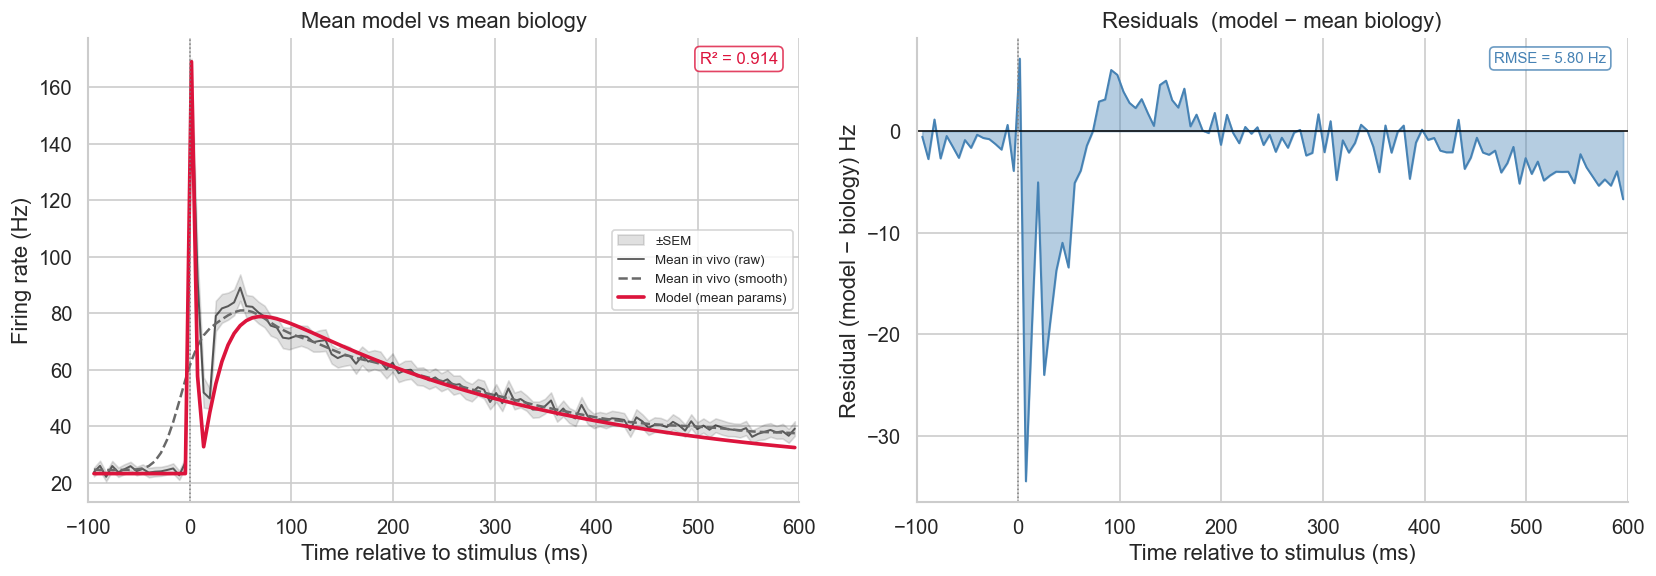

In [136]:
all_param_names = [
    "I_baseline", "A_fast", "A_phasic", "tau_decay",
    "J1", "KAPPA", "J0", "U_floor",
    "T_phasic", "tau_neural", "fc_stim_duration", "t_delay",
]

# ── 1. average model parameters (all cells with params) ───────────────────
pool_avg = df.dropna(subset=all_param_names)
mean_params = {p: float(pool_avg[p].mean()) for p in all_param_names}
t_delay_avg = mean_params.pop("t_delay")

print("Mean parameters:")
for k, v in {**mean_params, "t_delay": t_delay_avg}.items():
    print(f"  {k:22s} = {v:.3f}")

# ── 2. average biological PSTH across all cells with stim data ────────────
all_psths = []
for _, row in pool_avg.iterrows():
    aid = str(row["Animal_Id"])
    cid = str(int(float(row["Cell_Id"])))
    key = (aid, cid)
    if key not in _stim_lookup:
        continue
    hd_angle = float(row["HDAngle"]) if "HDAngle" in row and pd.notna(row["HDAngle"]) else 0.0
    psth = _cell_psth(_stim_lookup[key], hd_angle)
    if psth.max() > 0.5:
        all_psths.append(psth)

all_psths  = np.vstack(all_psths)
mean_bio   = all_psths.mean(axis=0)
sem_bio    = all_psths.std(axis=0) / np.sqrt(all_psths.shape[0])
smooth_bio = gaussian_filter1d(mean_bio.astype(float), sigma=SMOOTH_SIGMA)

t_vivo = BINS_PLOT - t_delay_avg
vmask  = (t_vivo >= WIN_LO) & (t_vivo <= WIN_HI)

print(f"\nCells contributing to average PSTH: {all_psths.shape[0]}")

# ── 3. run model with mean params ─────────────────────────────────────────
t_model, pd_trace = _run_model(mean_params)
mmask = (t_model >= WIN_LO) & (t_model <= WIN_HI)

interp_fn     = interp1d(t_model[mmask], pd_trace[mmask],
                          bounds_error=False, fill_value="extrapolate")
model_at_vivo = interp_fn(t_vivo[vmask])

# ── 4. R² of mean model vs mean biology ───────────────────────────────────
bio_w  = mean_bio[vmask]
ss_res = np.sum((bio_w - model_at_vivo) ** 2)
ss_tot = np.sum((bio_w - bio_w.mean()) ** 2)
r2_avg = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
print(f"\nR² (mean model vs mean biology): {r2_avg:.4f}")

# ── 5. plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: traces
ax = axes[0]
ax.fill_between(t_vivo[vmask],
                mean_bio[vmask] - sem_bio[vmask],
                mean_bio[vmask] + sem_bio[vmask],
                color="black", alpha=0.12, label="±SEM")
ax.plot(t_vivo[vmask], mean_bio[vmask],
        color="black", lw=1.2, alpha=0.6, label="Mean in vivo (raw)")
ax.plot(t_vivo[vmask], smooth_bio[vmask],
        color="dimgray", lw=1.5, linestyle="--", label="Mean in vivo (smooth)")
ax.plot(t_vivo[vmask], model_at_vivo,
        color="crimson", lw=2.2, label="Model (mean params)")
ax.axvline(0, color="gray", linestyle=":", lw=0.9)
ax.set_xlim(WIN_LO, WIN_HI)
ax.set_xlabel("Time relative to stimulus (ms)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("Mean model vs mean biology")
ax.legend(fontsize=8)
ax.text(0.97, 0.97, f"R² = {r2_avg:.3f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="crimson",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="crimson", alpha=0.8))

# right: residuals
ax2 = axes[1]
residuals = model_at_vivo - mean_bio[vmask]
rmse = np.sqrt(np.mean(residuals ** 2))
ax2.fill_between(t_vivo[vmask], residuals, alpha=0.4, color="steelblue")
ax2.plot(t_vivo[vmask], residuals, color="steelblue", lw=1.2)
ax2.axhline(0, color="black", lw=0.9)
ax2.axvline(0, color="gray", linestyle=":", lw=0.9)
ax2.set_xlim(WIN_LO, WIN_HI)
ax2.set_xlabel("Time relative to stimulus (ms)")
ax2.set_ylabel("Residual (model − biology) Hz")
ax2.set_title("Residuals  (model − mean biology)")
ax2.text(0.97, 0.97, f"RMSE = {rmse:.2f} Hz",
         transform=ax2.transAxes, ha="right", va="top",
         fontsize=9, color="steelblue",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="steelblue", alpha=0.8))

plt.tight_layout()
plt.show()

Running mean model (full spatial)...


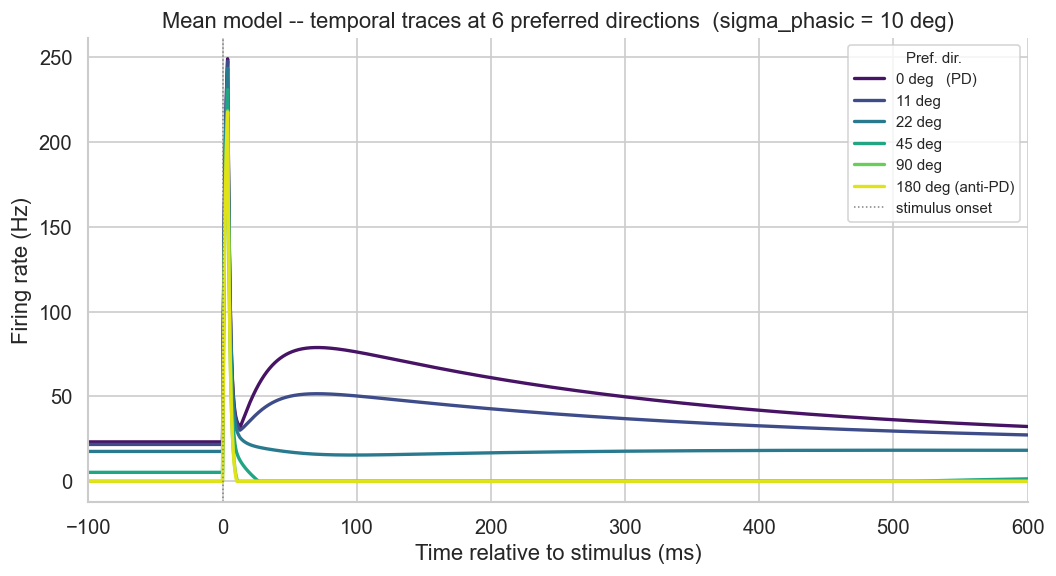

In [137]:
# indices for comparison angles (0deg already defined in cell 29 as _IDX_0)
_IDX_11_25 = np.argmin(np.abs(_THETA - np.pi / 16))
_IDX_22_5  = np.argmin(np.abs(_THETA - np.pi / 8))
_IDX_45    = np.argmin(np.abs(_THETA - np.pi / 4))
_IDX_90    = np.argmin(np.abs(_THETA - np.pi / 2))
_IDX_180   = np.argmin(np.abs(_THETA - np.pi))

COMPARE_ANGLES = [
    (0,     _IDX_0,     "0 deg   (PD)"),
    (11.25, _IDX_11_25, "11 deg"),
    (22.5,  _IDX_22_5,  "22 deg"),
    (45,    _IDX_45,    "45 deg"),
    (90,    _IDX_90,    "90 deg"),
    (180,   _IDX_180,   "180 deg (anti-PD)"),
]

# run mean model -- full spatial output
def _run_model_full(params):
    W         = (params["J1"] * np.exp(params["KAPPA"] * (_COS_D_THETA - 1.0)) - params["J0"]) / _N
    u         = 40.0 * np.maximum(0, np.cos(_THETA))
    r         = np.maximum(0, u)
    rates_all = np.zeros((len(_TIME), _N))
    sigma_rad = np.deg2rad(_SIGMA_PHASIC)
    fc_end    = _T_STIM + params["fc_stim_duration"]

    for step, t in enumerate(_TIME):
        I_ext = np.ones(_N) * params["I_baseline"]
        if _T_STIM <= t < fc_end:
            I_ext += params["A_fast"]
        elif t >= params["T_phasic"]:
            decay = np.exp(-(t - params["T_phasic"]) / params["tau_decay"])
            I_ext += params["A_phasic"] * decay * np.exp(-0.5 * (_THETA / sigma_rad) ** 2)
        u += (-u + W @ r + I_ext) * (_DT / params["tau_neural"])
        u  = np.maximum(params["U_floor"], u)
        r  = np.maximum(0, u)
        rates_all[step] = r

    mask = _TIME >= 0
    return _TIME[mask] - _T_STIM, rates_all[mask]

print("Running mean model (full spatial)...")
t_comp, rates_comp = _run_model_full(mean_params)
win = (t_comp >= WIN_LO) & (t_comp <= WIN_HI)

# plot
palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(COMPARE_ANGLES)))

fig, ax = plt.subplots(figsize=(9, 5))
for (ang_deg, idx, label), color in zip(COMPARE_ANGLES, palette):
    ax.plot(t_comp[win], rates_comp[win, idx], color=color, lw=2.0, label=label)

ax.axvline(0, color="gray", linestyle=":", lw=0.9, label="stimulus onset")
ax.set_xlim(WIN_LO, WIN_HI)
ax.set_xlabel("Time relative to stimulus (ms)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title(f"Mean model -- temporal traces at 6 preferred directions  (sigma_phasic = {_SIGMA_PHASIC} deg)")
ax.legend(title="Pref. dir.", fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.show()

## σ_phasic sweep — bump width vs phasic input width
`sigma_phasic` controls how broadly the phasic drive is injected spatially across the ring.  
Narrow σ → concentrated input near θ=0; broad σ → diffuse drive; attractor sharpens what it can.

Running σ_phasic sweep…
  σ=  5°  peak_FR=249.0 Hz  FWHM@t=150ms=19.0°
  σ= 10°  peak_FR=249.0 Hz  FWHM@t=150ms=29.0°
  σ= 20°  peak_FR=249.0 Hz  FWHM@t=150ms=41.0°
  σ= 45°  peak_FR=249.0 Hz  FWHM@t=150ms=51.0°
  σ= 90°  peak_FR=249.0 Hz  FWHM@t=150ms=59.0°


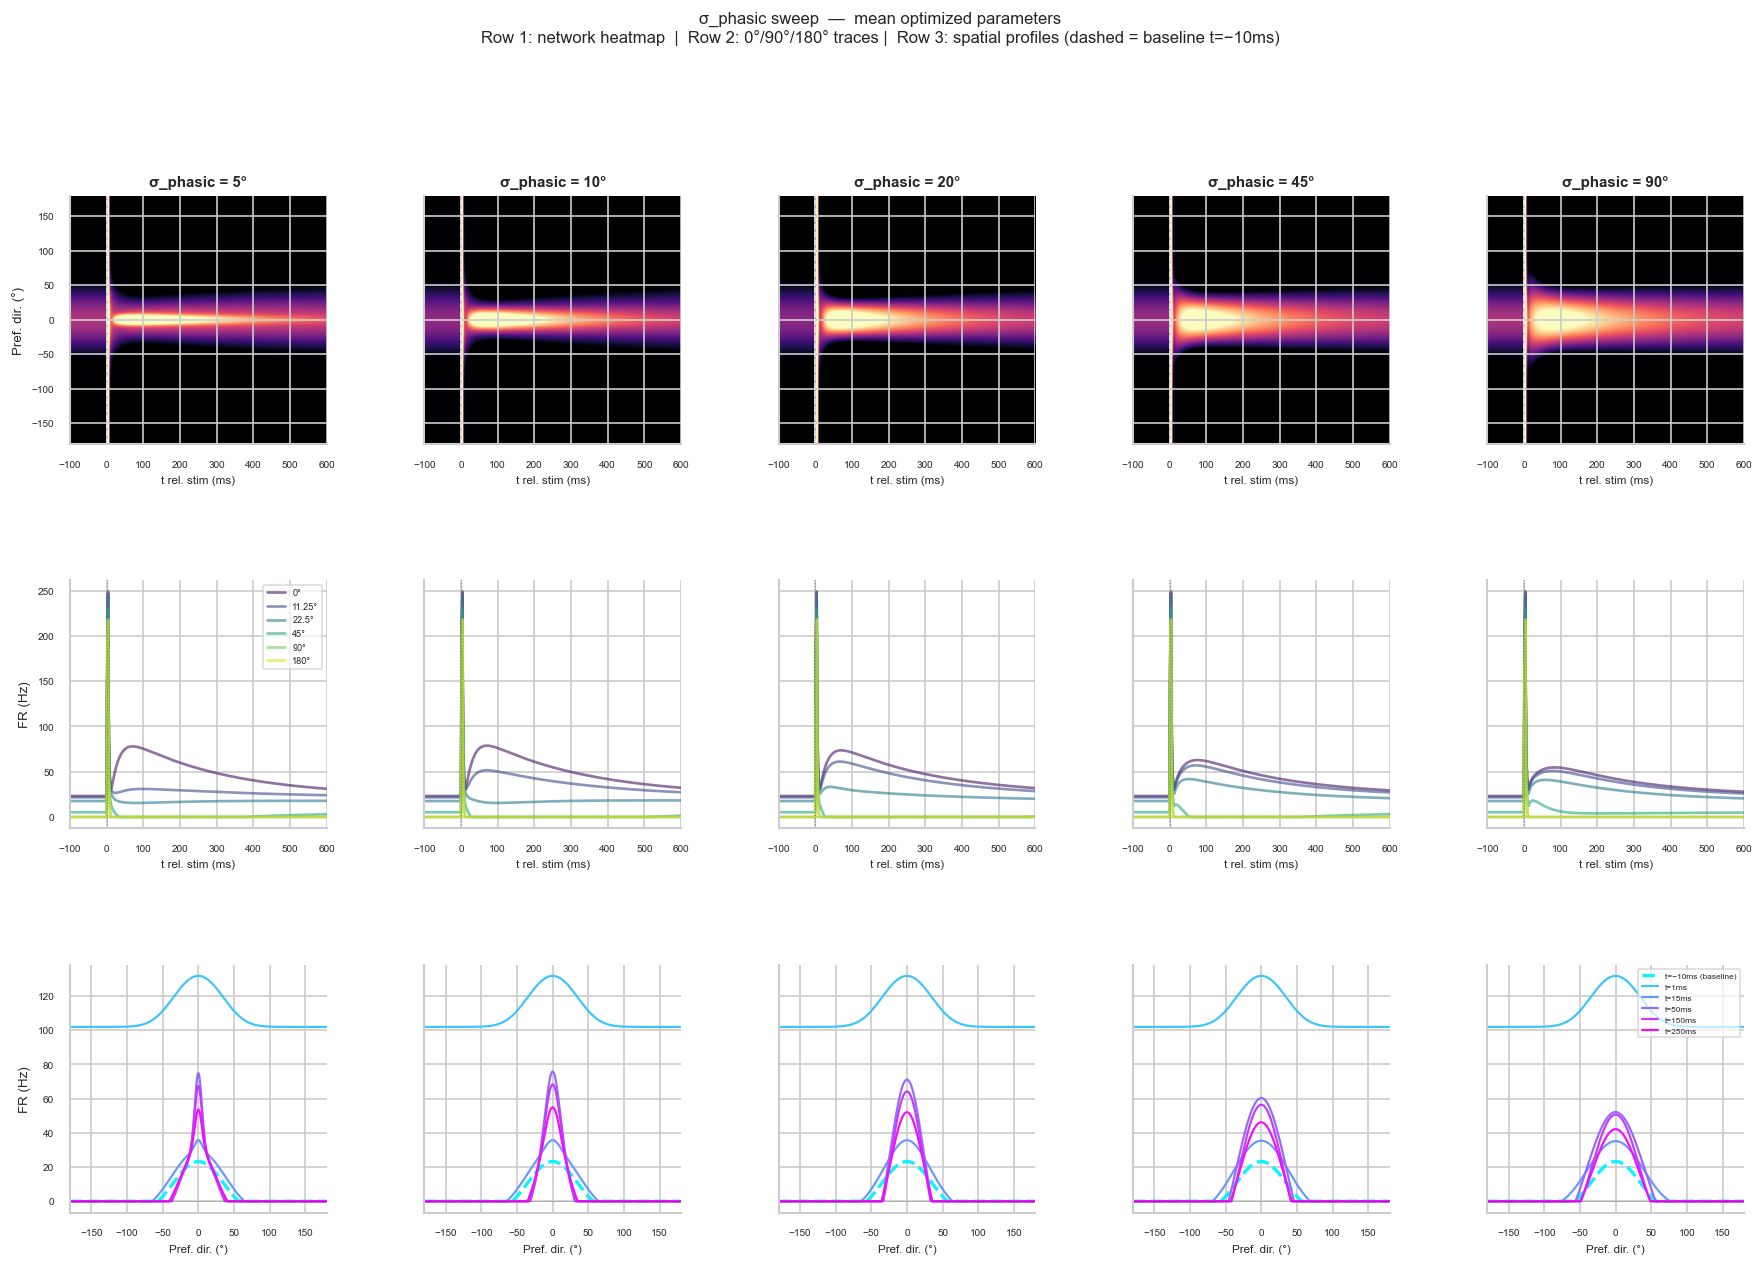

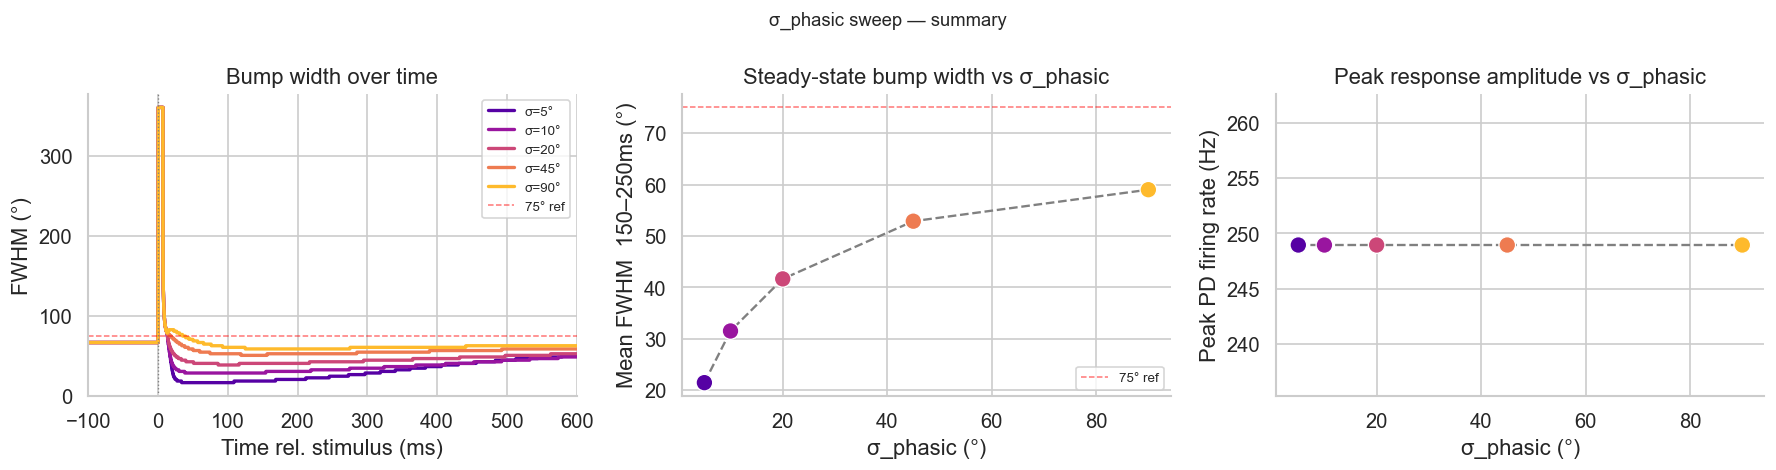

In [138]:
# ── requires: mean_params (from average model cell), _N/_THETA/_COS_D_THETA etc. ─
_IDX_180 = np.argmin(np.abs(_THETA - np.pi))
_IDX_90  = np.argmin(np.abs(_THETA - np.pi / 2))
_IDX_45 = np.argmin(np.abs(_THETA - np.pi / 4))
_IDX_22_5 = np.argmin(np.abs(_THETA - np.pi / 8))
_IDX_11_25 = np.argmin(np.abs(_THETA - np.pi / 16))

SIGMA_SWEEP   = [5, 10, 20, 45, 90]
T_SNAPS_REL   = [-10, 1, 15, 50, 150, 250]
SNAP_LABELS   = ["t=−10ms (baseline)", "t=1ms", "t=15ms", "t=50ms", "t=150ms", "t=250ms"]
PALETTE_SWEEP = plt.cm.plasma(np.linspace(0.15, 0.85, len(SIGMA_SWEEP)))
snap_colors   = plt.cm.cool(np.linspace(0.05, 0.95, len(T_SNAPS_REL)))
cell_num_cols = plt.cm.viridis(np.linspace(0.05, 0.95, 6))
theta_deg     = np.rad2deg(_THETA)


def _run_model_sigma(params: dict, sigma_phasic_deg: float):
    """Mean-param model run with overridden sigma_phasic (degrees)."""
    W         = (params["J1"] * np.exp(params["KAPPA"] * (_COS_D_THETA - 1.0)) - params["J0"]) / _N
    u         = 40.0 * np.maximum(0, np.cos(_THETA))
    r         = np.maximum(0, u)
    rates_all = np.zeros((len(_TIME), _N))
    sigma_rad = np.deg2rad(sigma_phasic_deg)
    fc_end    = _T_STIM + params["fc_stim_duration"]

    for step, t in enumerate(_TIME):
        I_ext = np.ones(_N) * params["I_baseline"]
        if _T_STIM <= t < fc_end:
            I_ext += params["A_fast"]
        elif t >= params["T_phasic"]:
            decay  = np.exp(-(t - params["T_phasic"]) / params["tau_decay"])
            I_ext += params["A_phasic"] * decay * np.exp(-0.5 * (_THETA / sigma_rad) ** 2)
        u += (-u + W @ r + I_ext) * (_DT / params["tau_neural"])
        u  = np.maximum(params["U_floor"], u)
        r  = np.maximum(0, u)
        rates_all[step] = r

    mask = _TIME >= 0
    return _TIME[mask] - _T_STIM, rates_all[mask]


def _fwhm_profile(profile: np.ndarray) -> float:
    peak = float(np.max(profile))
    if peak <= 1.0:
        return 0.0
    return float(np.sum(profile >= peak / 2.0)) * (360.0 / _N)


# ── run sweep ─────────────────────────────────────────────────────────────
print("Running σ_phasic sweep…")
sweep_results = {}
for sig in SIGMA_SWEEP:
    t_rel, rates = _run_model_sigma(mean_params, sig)
    fwhm_t       = np.array([_fwhm_profile(rates[i]) for i in range(len(t_rel))])
    sweep_results[sig] = {"t": t_rel, "rates": rates, "fwhm": fwhm_t}
    idx150 = np.argmin(np.abs(t_rel - 150))
    print(f"  σ={sig:3d}°  peak_FR={rates[:, _IDX_0].max():.1f} Hz  "
          f"FWHM@t=150ms={fwhm_t[idx150]:.1f}°")

# ─────────────────────────────────────────────────────────────────────────
# Figure 1 — per-sigma panels: heatmap | trace+FWHM | spatial profiles
# ─────────────────────────────────────────────────────────────────────────
n_sig = len(SIGMA_SWEEP)
fig   = plt.figure(figsize=(n_sig * 3.6, 11))
gs    = gridspec.GridSpec(3, n_sig, figure=fig, hspace=0.55, wspace=0.38)
for col_i, (sig, col) in enumerate(zip(SIGMA_SWEEP, PALETTE_SWEEP)):
    res  = sweep_results[sig]
    t    = res["t"]
    rt   = res["rates"]
    fwhm = res["fwhm"]
    win  = (t >= WIN_LO) & (t <= WIN_HI)

    # row 0 — network activity heatmap
    ax0 = fig.add_subplot(gs[0, col_i])
    ax0.imshow(
        rt[win].T, aspect="auto", origin="lower",
        extent=[float(t[win][0]), float(t[win][-1]), theta_deg[0], theta_deg[-1]],
        cmap="magma", vmin=0, vmax=float(np.percentile(rt[win], 98)),
    )
    ax0.axvline(0, color="white", lw=0.9, linestyle="--", alpha=0.7)
    ax0.set_title(f"σ_phasic = {sig}°", fontsize=9, fontweight="bold")
    ax0.set_xlim(WIN_LO, WIN_HI)
    ax0.tick_params(labelsize=6)
    if col_i == 0:
        ax0.set_ylabel("Pref. dir. (°)", fontsize=8)
    else:
        ax0.set_yticklabels([])
    ax0.set_xlabel("t rel. stim (ms)", fontsize=7)

    # row 1 — 0°/90°/180° traces + FWHM twin-y
    ax1 = fig.add_subplot(gs[1, col_i])
    
    ax1.plot(t[win], rt[win, _IDX_0], color = cell_num_cols[0], lw=1.6, label="0°", alpha=0.6)
    ax1.plot(t[win], rt[win, _IDX_11_25],color = cell_num_cols[1], lw=1.6, label="11.25°", alpha=0.6)
    ax1.plot(t[win], rt[win, _IDX_22_5], color = cell_num_cols[2],lw=1.6, label="22.5°", alpha=0.6)
    ax1.plot(t[win], rt[win, _IDX_45], color = cell_num_cols[3],lw=1.6, label="45°", alpha=0.6)
    ax1.plot(t[win], rt[win, _IDX_90], color = cell_num_cols[4],lw=1.6, label="90°", alpha=0.6)
    ax1.plot(t[win], rt[win, _IDX_180], color = cell_num_cols[5],lw=1.6, label="180°", alpha=0.6)
    ax1.axvline(0, color="gray", lw=0.7, linestyle=":")
    ax1.set_xlim(WIN_LO, WIN_HI)
    ax1.tick_params(labelsize=6)
    if col_i == 0:
        ax1.set_ylabel("FR (Hz)", fontsize=8)
        ax1.legend(fontsize=5.5, loc="upper right", framealpha=0.7)
    else:
        ax1.set_yticklabels([])
    ax1.set_xlabel("t rel. stim (ms)", fontsize=7)

    # ax1b = ax1.twinx()
    # ax1b.plot(t[win], fwhm[win], color="steelblue", lw=1.4, linestyle=":", alpha=0.85)
    # ax1b.axhline(75, color="steelblue", lw=0.6, alpha=0.35, linestyle="--")
    # ax1b.set_ylim(0, 380)
    # if col_i == n_sig - 1:
        # ax1b.set_ylabel("FWHM (°) — blue dotted", fontsize=7, color="steelblue")
    # else:
        # ax1b.set_yticklabels([])
    # ax1b.tick_params(labelsize=5, colors="steelblue")

    # row 2 — spatial profiles at snapshot times (including baseline at t=-10ms)
    ax2 = fig.add_subplot(gs[2, col_i])
    for t_snap, slabel, sc in zip(T_SNAPS_REL, SNAP_LABELS, snap_colors):
        idx_s = int(np.argmin(np.abs(t - t_snap)))
        lw    = 2.0 if t_snap < 0 else 1.3       # thicker line for baseline
        ls    = "--" if t_snap < 0 else "-"        # dashed for baseline
        ax2.plot(theta_deg, rt[idx_s], color=sc, lw=lw, linestyle=ls, label=slabel)
    ax2.axhline(0, color="black", lw=0.4, alpha=0.25)
    ax2.set_xlim(-180, 180)
    ax2.tick_params(labelsize=6)
    ax2.set_xlabel("Pref. dir. (°)", fontsize=7)
    if col_i == 0:
        ax2.set_ylabel("FR (Hz)", fontsize=8)
    else:
        ax2.set_yticklabels([])
    if col_i == n_sig - 1:
        ax2.legend(fontsize=5.0, loc="upper right", framealpha=0.7)

fig.suptitle(
    "σ_phasic sweep  —  mean optimized parameters\n"
    "Row 1: network heatmap  |  Row 2: 0°/90°/180° traces "
    "|  Row 3: spatial profiles (dashed = baseline t=−10ms)",
    fontsize=10, y=1.02,
)
plt.show()

# ─────────────────────────────────────────────────────────────────────────
# Figure 2 — summary: FWHM over time | steady-state FWHM | peak FR
# ─────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# FWHM over time — all sigmas overlaid
ax = axes2[0]
for sig, col in zip(SIGMA_SWEEP, PALETTE_SWEEP):
    res = sweep_results[sig]
    win = (res["t"] >= WIN_LO) & (res["t"] <= WIN_HI)
    ax.plot(res["t"][win], res["fwhm"][win], color=col, lw=2, label=f"σ={sig}°")
ax.axvline(0, color="gray", lw=0.8, linestyle=":")
ax.axhline(75, color="red", lw=0.9, linestyle="--", alpha=0.55, label="75° ref")
ax.set_xlim(WIN_LO, WIN_HI)
ax.set_xlabel("Time rel. stimulus (ms)")
ax.set_ylabel("FWHM (°)")
ax.set_title("Bump width over time")
ax.legend(fontsize=8)

# Steady-state FWHM (avg 150–250ms) vs sigma
ax = axes2[1]
fwhm_ss = []
for sig in SIGMA_SWEEP:
    res = sweep_results[sig]
    ss  = (res["t"] >= 150) & (res["t"] <= 250)
    fwhm_ss.append(float(res["fwhm"][ss].mean()) if ss.any() else 0.0)

ax.scatter(SIGMA_SWEEP, fwhm_ss, c=list(PALETTE_SWEEP), s=100,
           zorder=5, edgecolors="white", lw=0.8)
ax.plot(SIGMA_SWEEP, fwhm_ss, color="gray", lw=1.4, linestyle="--", zorder=4)
ax.axhline(75, color="red", lw=0.9, linestyle="--", alpha=0.55, label="75° ref")
ax.set_xlabel("σ_phasic (°)")
ax.set_ylabel("Mean FWHM  150–250ms (°)")
ax.set_title("Steady-state bump width vs σ_phasic")
ax.legend(fontsize=8)

# Peak PD firing rate vs sigma
ax = axes2[2]
peak_fr = [float(sweep_results[sig]["rates"][:, _IDX_0].max()) for sig in SIGMA_SWEEP]
ax.scatter(SIGMA_SWEEP, peak_fr, c=list(PALETTE_SWEEP), s=100,
           zorder=5, edgecolors="white", lw=0.8)
ax.plot(SIGMA_SWEEP, peak_fr, color="gray", lw=1.4, linestyle="--", zorder=4)
ax.set_xlabel("σ_phasic (°)")
ax.set_ylabel("Peak PD firing rate (Hz)")
ax.set_title("Peak response amplitude vs σ_phasic")

fig2.suptitle("σ_phasic sweep — summary", fontsize=11)
plt.tight_layout()
plt.show()

In [139]:
# ── σ_phasic sweep — printed analysis summary ────────────────────────────
# Requires sweep_results from the cell above.

SEP  = "=" * 72
SEP2 = "-" * 72

def _ss(sig, lo=150, hi=250):
    res = sweep_results[sig]
    m   = (res["t"] >= lo) & (res["t"] <= hi)
    return float(res["fwhm"][m].mean()) if m.any() else 0.0

def _pre(sig, lo=-50, hi=0):
    res = sweep_results[sig]
    m   = (res["t"] >= lo) & (res["t"] < hi)
    return float(res["fwhm"][m].mean()) if m.any() else 0.0

ss_fwhm  = {s: _ss(s)  for s in SIGMA_SWEEP}
pre_fwhm = {s: _pre(s) for s in SIGMA_SWEEP}

t_phasic_rel = mean_params["T_phasic"] - _T_STIM

print(SEP)
print("  σ_PHASIC SWEEP — BUMP WIDTH ANALYSIS SUMMARY")
print(f"  N = {_N} neurons   |   mean optimised parameters")
print(f"  Phasic drive onset : t_rel = {t_phasic_rel:.1f} ms  "
      f"(T_phasic = {mean_params['T_phasic']:.1f} ms)")
print(f"  tau_decay = {mean_params['tau_decay']:.1f} ms   |   "
      f"E/I balance J1/J0 = {mean_params['J1']/mean_params['J0']:.2f}")
print(SEP)

# ── per-sigma metrics table ───────────────────────────────────────────────
print(f"\n  {'σ':>4}  {'Input':>7}  {'Pre':>6}  {'Peak':>7}  "
      f"{'t_peak':>7}  {'@150ms':>7}  {'SS':>7}  {'Sharp':>7}")
print(f"  {'(°)':>4}  {'FWHM(°)':>7}  {'(°)':>6}  {'FWHM(°)':>7}  "
      f"{'(ms)':>7}  {'FWHM(°)':>7}  {'(°)':>7}  {'(%)':>7}")
print("  " + SEP2)

for sig in SIGMA_SWEEP:
    res     = sweep_results[sig]
    t, fwhm = res["t"], res["fwhm"]
    win     = (t >= WIN_LO) & (t <= WIN_HI)
    t_w, fw = t[win], fwhm[win]

    pk_i    = int(np.argmax(fw))
    pk_fw   = float(fw[pk_i])
    t_pk    = float(t_w[pk_i])
    fw150   = float(fwhm[int(np.argmin(np.abs(t - 150)))])
    ss_val  = ss_fwhm[sig]
    sharp   = (pk_fw - ss_val) / pk_fw * 100 if pk_fw > 0 else 0.0
    inp_fw  = sig * 2.355

    print(f"  {sig:>4}  {inp_fw:>7.0f}  {pre_fwhm[sig]:>6.1f}  {pk_fw:>7.1f}  "
          f"{t_pk:>7.1f}  {fw150:>7.1f}  {ss_val:>7.1f}  {sharp:>6.1f}%")

print(f"\n  Columns: σ (°) | Gaussian-input FWHM | pre-stim baseline FWHM |")
print(f"           bump-peak FWHM | time-of-peak (ms) | FWHM at t=150ms |")
print(f"           steady-state FWHM (avg 150–250ms) | attractor sharpening (%)")

# ── section 1: attractor sharpening ──────────────────────────────────────
print(f"\n{SEP}")
print("  1. ATTRACTOR SHARPENING")
print(f"     How much does the ring attractor compress the input FWHM?")
print(SEP2)

for sig in SIGMA_SWEEP:
    inp   = sig * 2.355
    ss    = ss_fwhm[sig]
    ratio = inp / ss if ss > 0 else float("nan")
    if ratio > 4:
        tag = "    strong sharpening"
    elif ratio > 2:
        tag = "    moderate sharpening"
    elif ratio > 1.1:
        tag = "    weak sharpening"
    else:
        tag = "      attractor width-limited"
    print(f"  σ={sig:3d}°  input {inp:.0f}° → SS {ss:.1f}°  "
          f"({ratio:.1f}×){tag}")

# ── section 2: FWHM temporal trajectory ──────────────────────────────────
print(f"\n{SEP}")
print("  2. FWHM TEMPORAL TRAJECTORY  (pre-stim → peak → stabilisation)")
print(SEP2)

for sig in SIGMA_SWEEP:
    res    = sweep_results[sig]
    t, fw  = res["t"], res["fwhm"]
    win    = (t >= WIN_LO) & (t <= WIN_HI)
    t_w, fw_w = t[win], fw[win]

    pk_i   = int(np.argmax(fw_w))
    pk_fw  = float(fw_w[pk_i])
    t_pk   = float(t_w[pk_i])
    ss     = ss_fwhm[sig]

    # first time post-peak where FWHM ≤ 110% of SS
    post   = np.where(np.arange(len(fw_w)) > pk_i)[0]
    near   = post[fw_w[post] <= ss * 1.1] if post.size > 0 else np.array([])
    t_stab = float(t_w[near[0]]) if near.size > 0 else float("nan")
    rise   = t_pk
    decay  = t_stab - t_pk if np.isfinite(t_stab) else float("nan")

    print(f"  σ={sig:3d}°  "
          f"baseline {pre_fwhm[sig]:.0f}°  "
          f"→ peaks at {pk_fw:.0f}° (t={t_pk:.0f}ms, rise={rise:.0f}ms)  "
          f"→ stable ~{ss:.0f}° at t≈{t_stab:.0f}ms  "
          f"(decay {decay:.0f}ms)")

# ── section 3: peak FR vs sigma ───────────────────────────────────────────
print(f"\n{SEP}")
print("  3. PEAK PD FIRING RATE vs σ_phasic")
print(f"     Broader input = drive spread over more cells = lower per-cell peak")
print(SEP2)

peak_frs = {sig: float(sweep_results[sig]["rates"][:, _IDX_0].max()) for sig in SIGMA_SWEEP}
max_fr   = max(peak_frs.values())
for sig in SIGMA_SWEEP:
    fr   = peak_frs[sig]
    bar  = "█" * int(round(fr / max_fr * 30))
    print(f"  σ={sig:3d}°  {fr:6.1f} Hz  {bar}")

# ── section 4: key finding ────────────────────────────────────────────────
closest = min(SIGMA_SWEEP, key=lambda s: abs(ss_fwhm[s] - 75))
ss_vals = [ss_fwhm[s] for s in SIGMA_SWEEP]
mono    = all(ss_vals[i] <= ss_vals[i+1] for i in range(len(ss_vals)-1))

print(f"\n{SEP}")
print("  4. KEY FINDINGS")
print(SEP2)
print(f"  • Steady-state FWHM range  : {min(ss_vals):.1f}° – {max(ss_vals):.1f}°  "
      f"({'monotonic ↑' if mono else 'non-monotonic'} with σ)")
print(f"  • Closest to 75° target    : σ = {closest}°  (SS = {ss_fwhm[closest]:.1f}°)")
print(f"  • Phasic drive onset       : t = {t_phasic_rel:.1f} ms  "
      f"→ FWHM expands immediately after this point")
print(f"  • Peak FWHM always occurs  : within {max(float(sweep_results[s]['t'][(sweep_results[s]['t']>=WIN_LO)&(sweep_results[s]['t']<=WIN_HI)][np.argmax(sweep_results[s]['fwhm'][(sweep_results[s]['t']>=WIN_LO)&(sweep_results[s]['t']<=WIN_HI)])]) for s in SIGMA_SWEEP):.0f} ms of stimulus")
print(f"  • Attractor role           : J1/J0 = {mean_params['J1']/mean_params['J0']:.2f}  "
      f"→ ring sharpens all but the broadest inputs")
print(SEP)

  σ_PHASIC SWEEP — BUMP WIDTH ANALYSIS SUMMARY
  N = 360 neurons   |   mean optimised parameters
  Phasic drive onset : t_rel = 13.1 ms  (T_phasic = 113.1 ms)
  tau_decay = 239.7 ms   |   E/I balance J1/J0 = 1.09

     σ    Input     Pre     Peak   t_peak   @150ms       SS    Sharp
   (°)  FWHM(°)     (°)  FWHM(°)     (ms)  FWHM(°)      (°)      (%)
  ------------------------------------------------------------------------
     5       12    67.0    360.0      0.4     19.0     21.5    94.0%
    10       24    67.0    360.0      0.4     29.0     31.5    91.2%
    20       47    67.0    360.0      0.4     41.0     41.7    88.4%
    45      106    67.0    360.0      0.4     51.0     52.9    85.3%
    90      212    67.0    360.0      0.4     59.0     59.0    83.6%

  Columns: σ (°) | Gaussian-input FWHM | pre-stim baseline FWHM |
           bump-peak FWHM | time-of-peak (ms) | FWHM at t=150ms |
           steady-state FWHM (avg 150–250ms) | attractor sharpening (%)

  1. ATTRACTOR SHARPEN

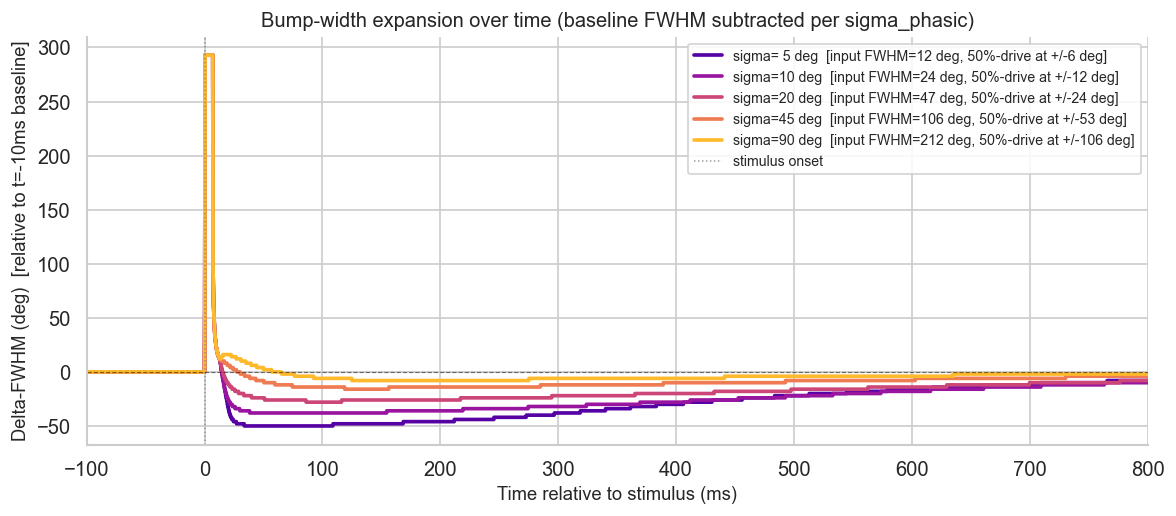

In [140]:
# ── FWHM over time — baseline-subtracted ──────────────────────────────────
# Subtract each sigma's pre-stimulus FWHM (t=-10ms) so all traces start at 0.
# Legend: input FWHM and the +/-half-max reach (cells beyond get <50% drive).

fig, ax = plt.subplots(figsize=(10, 4.5))

for sig, col in zip(SIGMA_SWEEP, PALETTE_SWEEP):
    res  = sweep_results[sig]
    t    = res['t']
    fwhm = res['fwhm']
    win  = (t >= WIN_LO) & (t <= WIN_HI + 200)

    idx_base  = int(np.argmin(np.abs(t - (-10.0))))
    fwhm_base = fwhm[idx_base]

    inp_fwhm   = sig * 2.355      # FWHM of the Gaussian input
    half_reach = sig * 1.177      # angle where drive falls to 50% of peak
    lbl = (f'sigma={sig:2d} deg  '
           f'[input FWHM={inp_fwhm:.0f} deg, '
           f'50%-drive at +/-{half_reach:.0f} deg]')
    ax.plot(t[win], fwhm[win] - fwhm_base, color=col, lw=2.2, label=lbl)

ax.axvline(0,  color='gray',  lw=0.9, linestyle=':',  alpha=0.8, label='stimulus onset')
ax.axhline(0,  color='black', lw=0.7, linestyle='--', alpha=0.5)
ax.set_xlim(WIN_LO, WIN_HI + 200)
ax.set_xlabel('Time relative to stimulus (ms)', fontsize=11)
ax.set_ylabel('Delta-FWHM (deg)  [relative to t=-10ms baseline]', fontsize=11)
ax.set_title('Bump-width expansion over time (baseline FWHM subtracted per sigma_phasic)',
             fontsize=12)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
plt.tight_layout()
plt.show()


--- Significant Biological Correlations (p < 0.05) ---
Membrane_Reactivity vs HDpeakFRsmooth: r = +0.519 (p=0.0000)
Membrane_Reactivity vs HDpeakFR: r = +0.466 (p=0.0000)
Membrane_Reactivity vs nSpk: r = +0.297 (p=0.0088)
Membrane_Reactivity vs HDFR: r = +0.413 (p=0.0002)
Phasic_Energy vs nSpk: r = +0.306 (p=0.0068)
Phasic_Energy vs HDFR: r = +0.322 (p=0.0043)
EI_Balance vs HDpeakFRsmooth: r = -0.236 (p=0.0388)
EI_Balance vs HDpeakFR: r = -0.247 (p=0.0301)


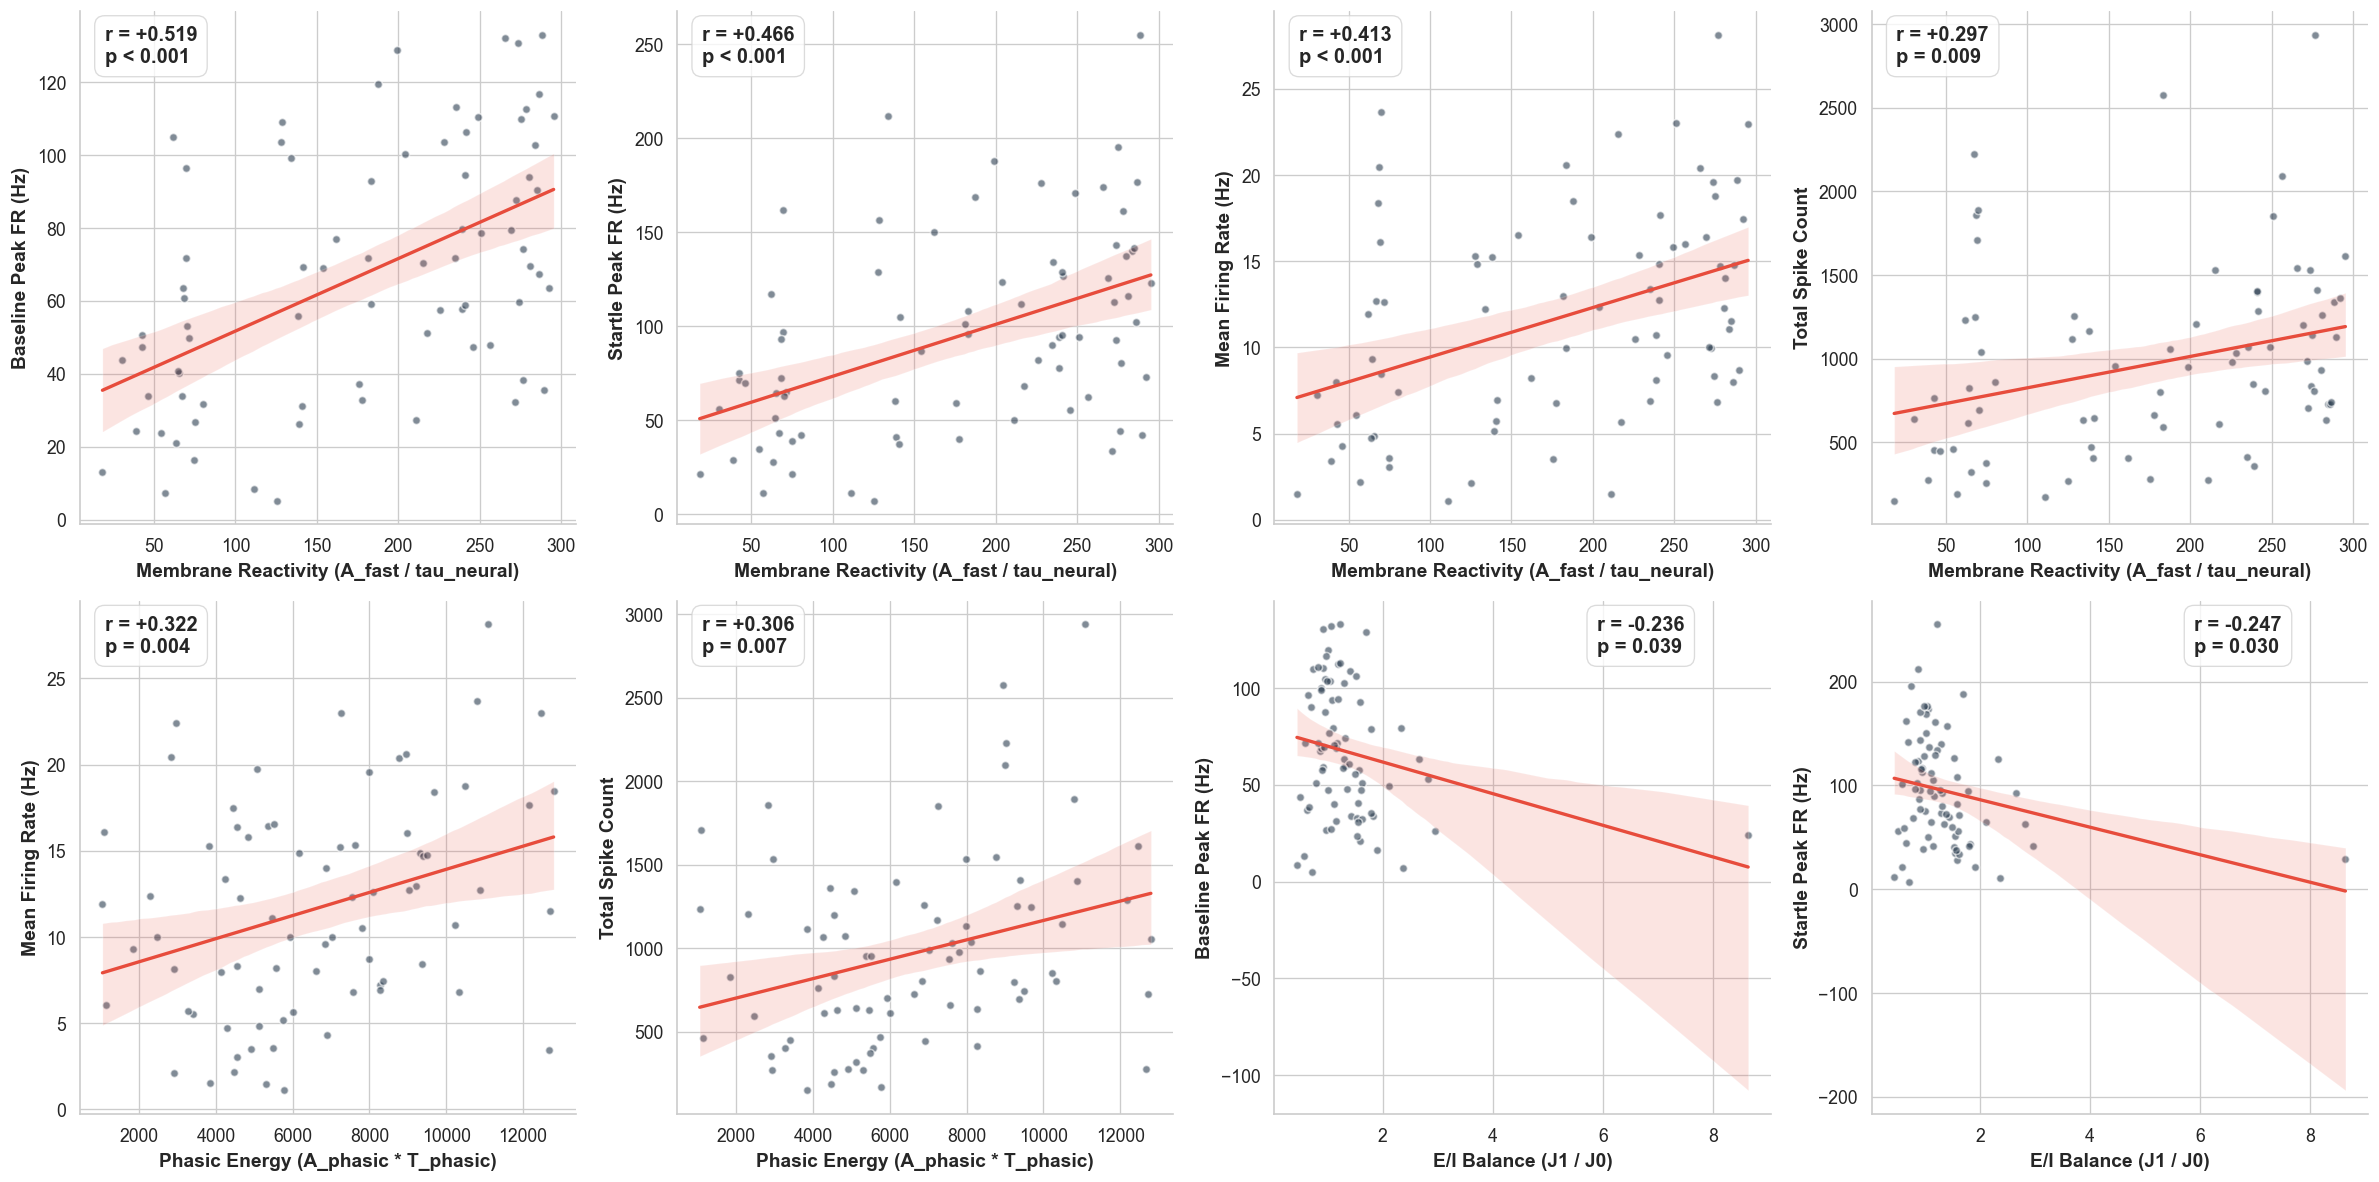

In [141]:
df['Membrane_Reactivity'] = df['A_fast'] / df['tau_neural']
df['Phasic_Energy'] = df['A_phasic'] * df['T_phasic']
df['EI_Balance'] = df['J1'] / df['J0']
df.to_csv('df.csv', index=False)
# Drop non-numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])

print("--- Significant Biological Correlations (p < 0.05) ---")
for col in ['Membrane_Reactivity', 'Phasic_Energy', 'EI_Balance']:
    for bio_metric in ['HDpeakFRsmooth', 'HDpeakFR', 'nSpk', 'HDFR', 'vm_kappa', 'HDInx']:
        # Drop NaNs to avoid calculation errors
        valid_data = numeric_df[[col, bio_metric]].dropna()
        if len(valid_data) > 2:
            r, p = pearsonr(valid_data[col], valid_data[bio_metric])
            if p < 0.05:
                print(f"{col} vs {bio_metric}: r = {r:+.3f} (p={p:.4f})")

# Set up the visual style for a clean, scientific look
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Define the exact significant pairs from your results
significant_pairs = [
    # Membrane Reactivity
    ('Membrane_Reactivity', 'HDpeakFRsmooth'),
    ('Membrane_Reactivity', 'HDpeakFR'),
    ('Membrane_Reactivity', 'HDFR'),
    ('Membrane_Reactivity', 'nSpk'),
    
    # Phasic Energy
    ('Phasic_Energy', 'HDFR'),
    ('Phasic_Energy', 'nSpk'),
    
    # E/I Balance
    ('EI_Balance', 'HDpeakFRsmooth'),
    ('EI_Balance', 'HDpeakFR')
]

# Create a figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Titles for the axes to make them look professional
axis_labels = {
    'Membrane_Reactivity': 'Membrane Reactivity (A_fast / tau_neural)',
    'Phasic_Energy': 'Phasic Energy (A_phasic * T_phasic)',
    'EI_Balance': 'E/I Balance (J1 / J0)',
    'HDpeakFRsmooth': 'Baseline Peak FR (Hz)',
    'HDpeakFR': 'Startle Peak FR (Hz)',
    'HDFR': 'Mean Firing Rate (Hz)',
    'nSpk': 'Total Spike Count'
}

for i, (x_col, y_col) in enumerate(significant_pairs):
    ax = axes[i]
    
    # Drop NaNs just for this specific pair to avoid calculation errors
    plot_data = df[[x_col, y_col]].dropna()
    
    # Plot the scatter and regression line
    sns.regplot(
        data=plot_data, 
        x=x_col, 
        y=y_col, 
        ax=ax,
        scatter_kws={'alpha': 0.6, 'color': '#2C3E50', 'edgecolor': 'w'},
        line_kws={'color': '#E74C3C', 'linewidth': 2}
    )
    
    # Calculate stats for the annotation
    r, p = pearsonr(plot_data[x_col], plot_data[y_col])
    
    # Format the p-value nicely
    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    
    # Add a text box with the stats in the top left/right corner
    # If r is positive, put text in top left. If negative, top right.
    x_pos = 0.05 if r > 0 else 0.65
    ax.text(
        x_pos, 0.90, 
        f"r = {r:+.3f}\n{p_text}", 
        transform=ax.transAxes, 
        fontsize=12,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgrey', boxstyle='round,pad=0.5')
    )
    
    # Set clean labels
    ax.set_xlabel(axis_labels.get(x_col, x_col), fontweight='bold')
    ax.set_ylabel(axis_labels.get(y_col, y_col), fontweight='bold')
    
    # Despine for a cleaner look
    sns.despine(ax=ax)

# Adjust layout so subplots don't overlap
plt.tight_layout()

# Save the figure at high resolution
plt.savefig("biological_correlations_grid.png", dpi=300, bbox_inches='tight')
plt.show()